# Exploración ICS e IPM

Carga de shapefiles desde el repositorio, visualización en mapa y análisis inicial del Índice de Condición Social (ICS) y el Índice de Pobreza Multidimensional (IPM) a nivel de manzana.


In [115]:
# @title 1. Montar Google Drive (opcional, solo en Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive montado')
else:
    print('Ejecutando localmente')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado


In [116]:
# @title 2. Instalar dependencias
!pip install geopandas matplotlib mapclassify pyarrow openpyxl pyogrio -q


In [117]:
# @title 3. Clonar el repositorio (solo si es necesario)
import os
import shutil

REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    %cd {REPO_DIR}
    !git pull
    %cd ..
print('Repositorio listo')


/content/Pobreza_multidimensional_y_condicion_social
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Total 7 (delta 6), reused 7 (delta 6), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 1.25 MiB | 901.00 KiB/s, done.
From https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social
   e397c0f..a3640b7  main       -> origin/main
Updating e397c0f..a3640b7
Fast-forward
 .../notebooks_py/01_exploracion_ics_ipm.ipynb      | 247 ++++++++++++---------
 .../notebooks_py/04_mapeo_ipm_roosevelt.ipynb      |   6 +-
 .../notebooks_py/05_mapeo_ipm_barrio_obrero.ipynb  |  15 +-
 3 files changed, 153 insertions(+), 115 deletions(-)
/content
Repositorio listo


In [118]:
# @title 4. Configuración de Idioma y Estilo Visual
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.patches as mpatches
from pathlib import Path

# Configuración para soporte de caracteres en español y resolución
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# Paleta global accesible para daltónicos
sns.set_palette("colorblind")

print("Entorno configurado: Soporte UTF-8 y paletas accesibles activadas.")
print('Librerías importadas')


Entorno configurado: Soporte UTF-8 y paletas accesibles activadas.
Librerías importadas


In [119]:
# @title 5. Definir rutas maestros
BASE_DIR = REPO_DIR if os.path.exists(REPO_DIR) else '.'
DATA_DIR = os.path.join(BASE_DIR, 'indice_Pobreza', 'data')
EXCEL_PATH = os.path.join(BASE_DIR, 'IPM - Variables (incidencias).xlsx')

# Rutas específicas de GeoJSON
PATH_ICS_GEO = os.path.join(DATA_DIR, 'geojosn_ICS', 'ics_mzn.geojson')
PATH_IPM_GEO = os.path.join(DATA_DIR, 'geojson_ipm', 'Mzn_ipm_variables.geojson')
PATH_ITT_DIR = os.path.join(DATA_DIR, 'geojson_poligonos_territorio_ITT')
PATH_COMUNAS = os.path.join(DATA_DIR, 'geojson_comunas', 'Comunas.geojson')

print(f'Archivo ICS existe: {os.path.exists(PATH_ICS_GEO)}')
print(f'Archivo IPM existe: {os.path.exists(PATH_IPM_GEO)}')
print(f'Excel existe: {os.path.exists(EXCEL_PATH)}')


Archivo ICS existe: True
Archivo IPM existe: True
Excel existe: True


In [120]:
# @title 6. Cargar GeoJSON maestros
gdf_ics = gpd.read_file(PATH_ICS_GEO)
gdf_ipm = gpd.read_file(PATH_IPM_GEO)

# Corrección de seguridad para ICS: 
# Si las coordenadas están en metros (>1000) pero el CRS es EPSG:4326, ajustamos.
if gdf_ics.total_bounds[0] > 1000:
    print('Ajustando CRS de ICS (Metros detectados en archivo con etiqueta geográfica)...')
    CALI_GRID = 'PROJCS["MAGNA-SIRGAS / Cali urban grid",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",3.44188333333333],PARAMETER["central_meridian",-76.5205625],PARAMETER["scale_factor",1],PARAMETER["false_easting",1061900.18],PARAMETER["false_northing",872364.63],UNIT["m",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'
    gdf_ics.set_crs(CALI_GRID, allow_override=True, inplace=True)
    # Reproyectar a WGS84 para visualización y cruces con IPM
    gdf_ics = gdf_ics.to_crs(epsg=4326)

# Normalizar columnas de IPM para compatibilidad con el resto del notebook
gdf_ipm.columns = [c.lower() for c in gdf_ipm.columns]
cols_incidencia = ['analf_', 'bajo_', 'infancia_', 'inasis_', 'rezago_', 'trab_infan', 'depen_', 'infor_', 'salud_', 'asegu_', 'haci_', 'pared_', 'excre_', 'pisos_', 'agua_']
for col in cols_incidencia:
    if col in gdf_ipm.columns:
        gdf_ipm[col + '_val'] = gdf_ipm[col]

# Definir gdf_vars como alias de gdf_ipm (ya contiene geometría y variables)
gdf_vars = gdf_ipm

print(f'ICS: {gdf_ics.shape[0]} geometrías, {gdf_ics.shape[1]} columnas')
print(f'IPM: {gdf_ipm.shape[0]} geometrías, {gdf_ipm.shape[1]} columnas')


ICS: 15658 geometrías, 6 columnas
IPM: 15658 geometrías, 39 columnas


In [121]:
# @title 7. Ver columnas disponibles
print('=== Columnas ICS ===')
print(gdf_ics.columns.tolist())
print()
print('=== Columnas IPM ===')
print(gdf_ipm.columns.tolist())


=== Columnas ICS ===
['COD_MZN', 'CLASE', 'ZONA', 'cod_dane_a', 'ics', 'geometry']

=== Columnas IPM ===
['cod_dpto', 'cod_mpio', 'cod_dane', 'ipm', 'oid_', 'cod_mzn', 'analf_', 'bajo_', 'infancia_', 'inasis_', 'rezago_', 'trab_infan', 'depen_', 'infor_', 'salud_', 'asegu_', 'haci_', 'pared_', 'excre_', 'pisos_', 'agua_', 'zona', 'zona2', 'geometry', 'analf__val', 'bajo__val', 'infancia__val', 'inasis__val', 'rezago__val', 'trab_infan_val', 'depen__val', 'infor__val', 'salud__val', 'asegu__val', 'haci__val', 'pared__val', 'excre__val', 'pisos__val', 'agua__val']


In [122]:
# @title 8. Vista previa de los datos
print('=== ICS (primeras 5 filas) ===')
display(gdf_ics.head())
print()
print('=== IPM (primeras 5 filas) ===')
display(gdf_ipm.head())


=== ICS (primeras 5 filas) ===


,COD_MZN,CLASE,ZONA,cod_dane_a,ics,geometry
0,7600110000000001010101,1.0,Urbana,7600110000000001010101,32.883636,"MULTIPOLYGON (((-76.5736 3.45369, -76.57297 3...."
1,7600110000000001010102,1.0,Urbana,7600110000000001010102,26.022223,"MULTIPOLYGON (((-76.57208 3.45399, -76.57208 3..."
2,7600110000000001010111,1.0,Urbana,7600110000000001010111,30.111376,"MULTIPOLYGON (((-76.5747 3.45543, -76.57469 3...."
3,7600110000000001010112,1.0,Urbana,7600110000000001010112,29.542585,"MULTIPOLYGON (((-76.57574 3.45462, -76.5759 3...."
4,7600110000000001010113,1.0,Urbana,7600110000000001010113,33.991302,"MULTIPOLYGON (((-76.57596 3.45568, -76.57592 3..."



=== IPM (primeras 5 filas) ===


,cod_dpto,cod_mpio,cod_dane,ipm,oid_,cod_mzn,analf_,bajo_,infancia_,inasis_,...,trab_infan_val,depen__val,infor__val,salud__val,asegu__val,haci__val,pared__val,excre__val,pisos__val,agua__val
0,76,76001,7600110000000001010101,5.7,0,7600110000000001010101,3.2520,34.1463,0.0000,0.0000,...,0.0000,14.6341,86.5854,1.6260,17.8862,7.7236,1.2195,0.0000,0.0000,3.6585
1,76,76001,7600110000000001010102,8.9,1,7600110000000001010102,0.0000,37.7778,0.0000,10.0000,...,3.3333,22.2222,73.3333,4.4444,24.4444,8.8889,0.0000,1.1111,0.0000,0.0000
2,76,76001,7600110000000001010111,6.3,2,7600110000000001010111,7.9365,48.1481,0.0000,0.0000,...,0.0000,14.8148,82.5397,15.3439,12.1693,10.5820,1.5873,0.5291,0.5291,0.5291
3,76,76001,7600110000000001010112,10.5,3,7600110000000001010112,7.3930,30.7393,2.7237,5.4475,...,0.0000,22.9572,77.4319,2.3346,15.1751,10.8949,0.0000,0.0000,0.0000,0.0000
4,76,76001,7600110000000001010113,13.0,4,7600110000000001010113,6.9565,26.9565,5.2174,0.0000,...,0.0000,11.7391,80.8696,0.0000,27.3913,9.5652,0.0000,0.0000,0.0000,0.0000


In [123]:
# @title 9. Sistema de referencia de coordenadas (CRS)
print(f'ICS CRS: {gdf_ics.crs}')
print(f'IPM CRS: {gdf_ipm.crs}')


ICS CRS: EPSG:4326
IPM CRS: EPSG:4326


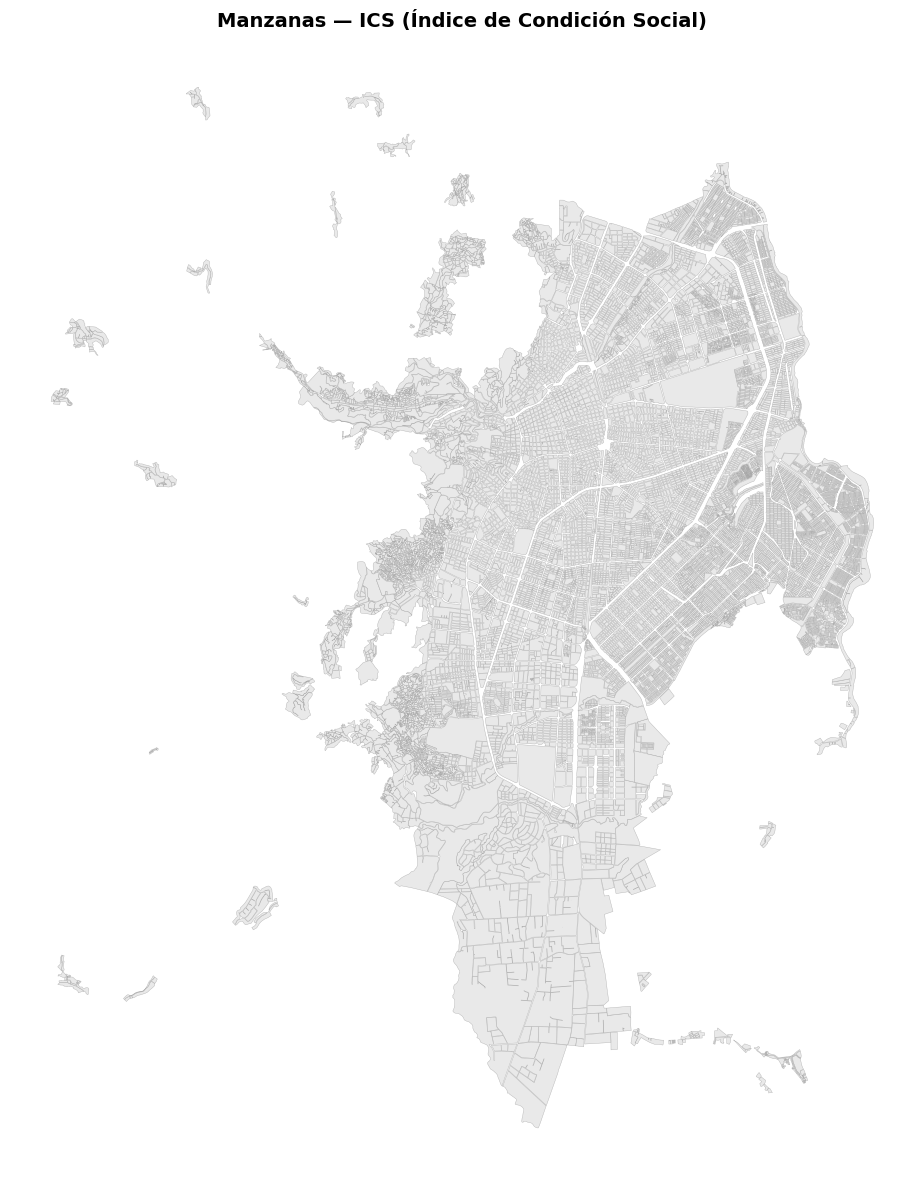

In [124]:
# @title 10. Mapa base — Manzanas ICS
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
gdf_ics.plot(ax=ax, color='#e0e0e0', edgecolor='#999999', linewidth=0.3, alpha=0.7)
ax.set_title('Manzanas — ICS (Índice de Condición Social)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


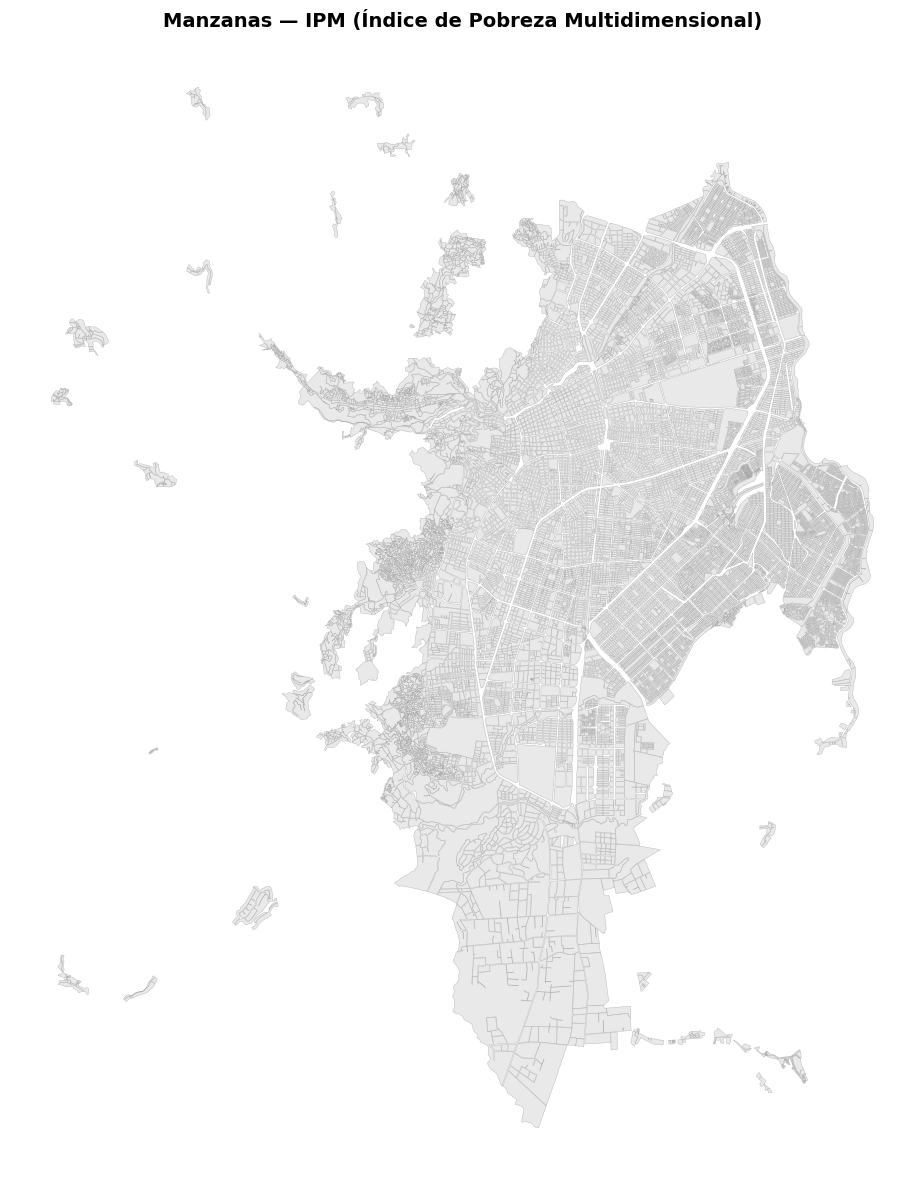

In [125]:
# @title 11. Mapa base — Manzanas IPM
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
gdf_ipm.plot(ax=ax, color='#e0e0e0', edgecolor='#999999', linewidth=0.3, alpha=0.7)
ax.set_title('Manzanas — IPM (Índice de Pobreza Multidimensional)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [126]:
# @title 12. Identificar columna de ICS para clasificación
# Buscar columna numérica que contenga el valor del ICS
ics_cols = [c for c in gdf_ics.columns if gdf_ics[c].dtype in ['float64', 'int64']]
print('Columnas numéricas en ICS:', ics_cols)

# Mostrar distribución de las primeras columnas numéricas
for col in ics_cols[:5]:
    print(f'\n{col}:')
    print(gdf_ics[col].describe())


Columnas numéricas en ICS: ['CLASE', 'ics']

CLASE:
count    15658.000000
mean         0.958807
std          0.336837
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: CLASE, dtype: float64

ics:
count    15658.000000
mean        29.804883
std         17.176787
min          0.000000
25%         21.582804
50%         29.552778
75%         39.000000
max        335.050018
Name: ics, dtype: float64


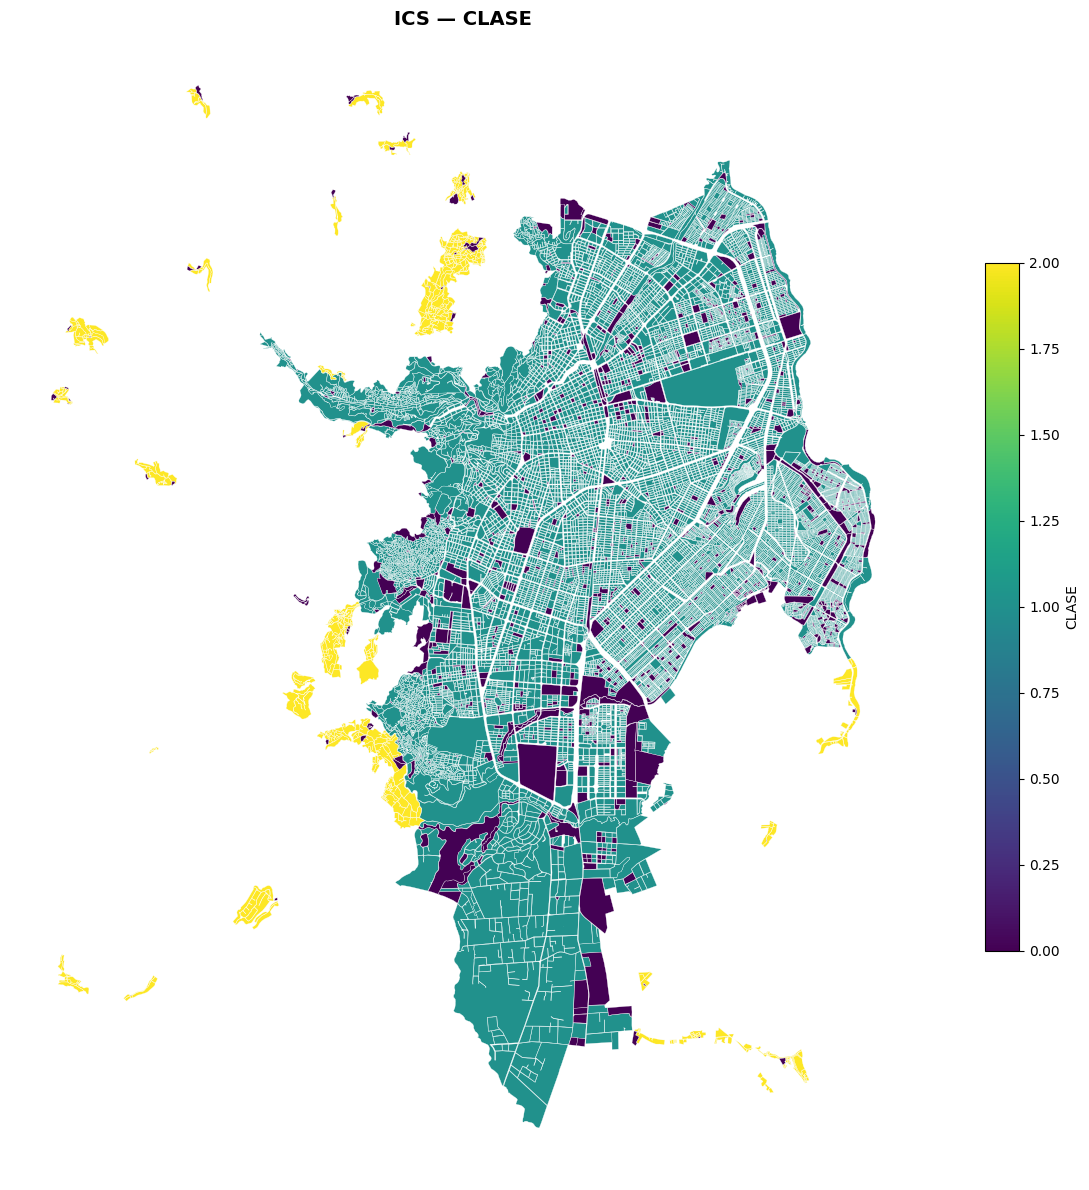

In [127]:
# @title 13. Mapa temático — ICS (si existe columna de valor)
# Identificar columna candidata para mapeo
num_cols_ics = [c for c in gdf_ics.columns if gdf_ics[c].dtype in ['float64', 'int64'] and c.lower() not in ['objectid', 'fid', 'id', 'shape_leng', 'shape_area', 'shape_len', 'shape_le']]

if num_cols_ics:
    col = num_cols_ics[0]
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    gdf_ics.plot(column=col, ax=ax, legend=True,
                 cmap='viridis', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': col, 'shrink': 0.6})
    ax.set_title(f'ICS — {col}', fontsize=14, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró columna numérica para mapear en ICS')


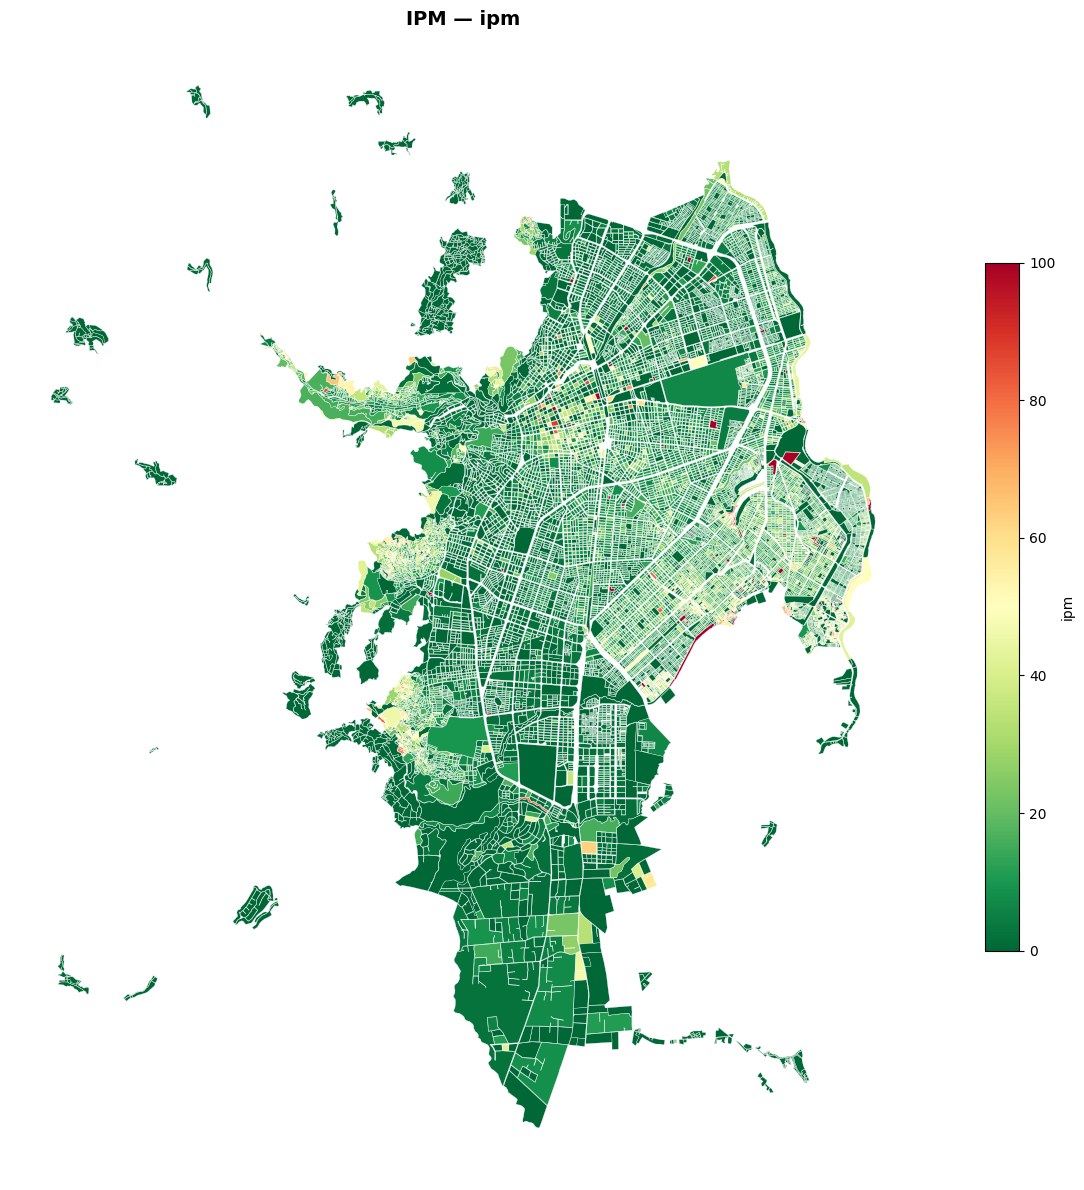

In [128]:
# @title 14. Mapa temático — IPM
num_cols_ipm = [c for c in gdf_ipm.columns if gdf_ipm[c].dtype in ['float64', 'int64'] and c.lower() not in ['objectid', 'fid', 'id', 'shape_leng', 'shape_area', 'shape_len', 'shape_le']]

if num_cols_ipm:
    col = num_cols_ipm[0]
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    gdf_ipm.plot(column=col, ax=ax, legend=True,
                 cmap='RdYlGn_r', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': col, 'shrink': 0.6})
    ax.set_title(f'IPM — {col}', fontsize=14, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró columna numérica para mapear en IPM')


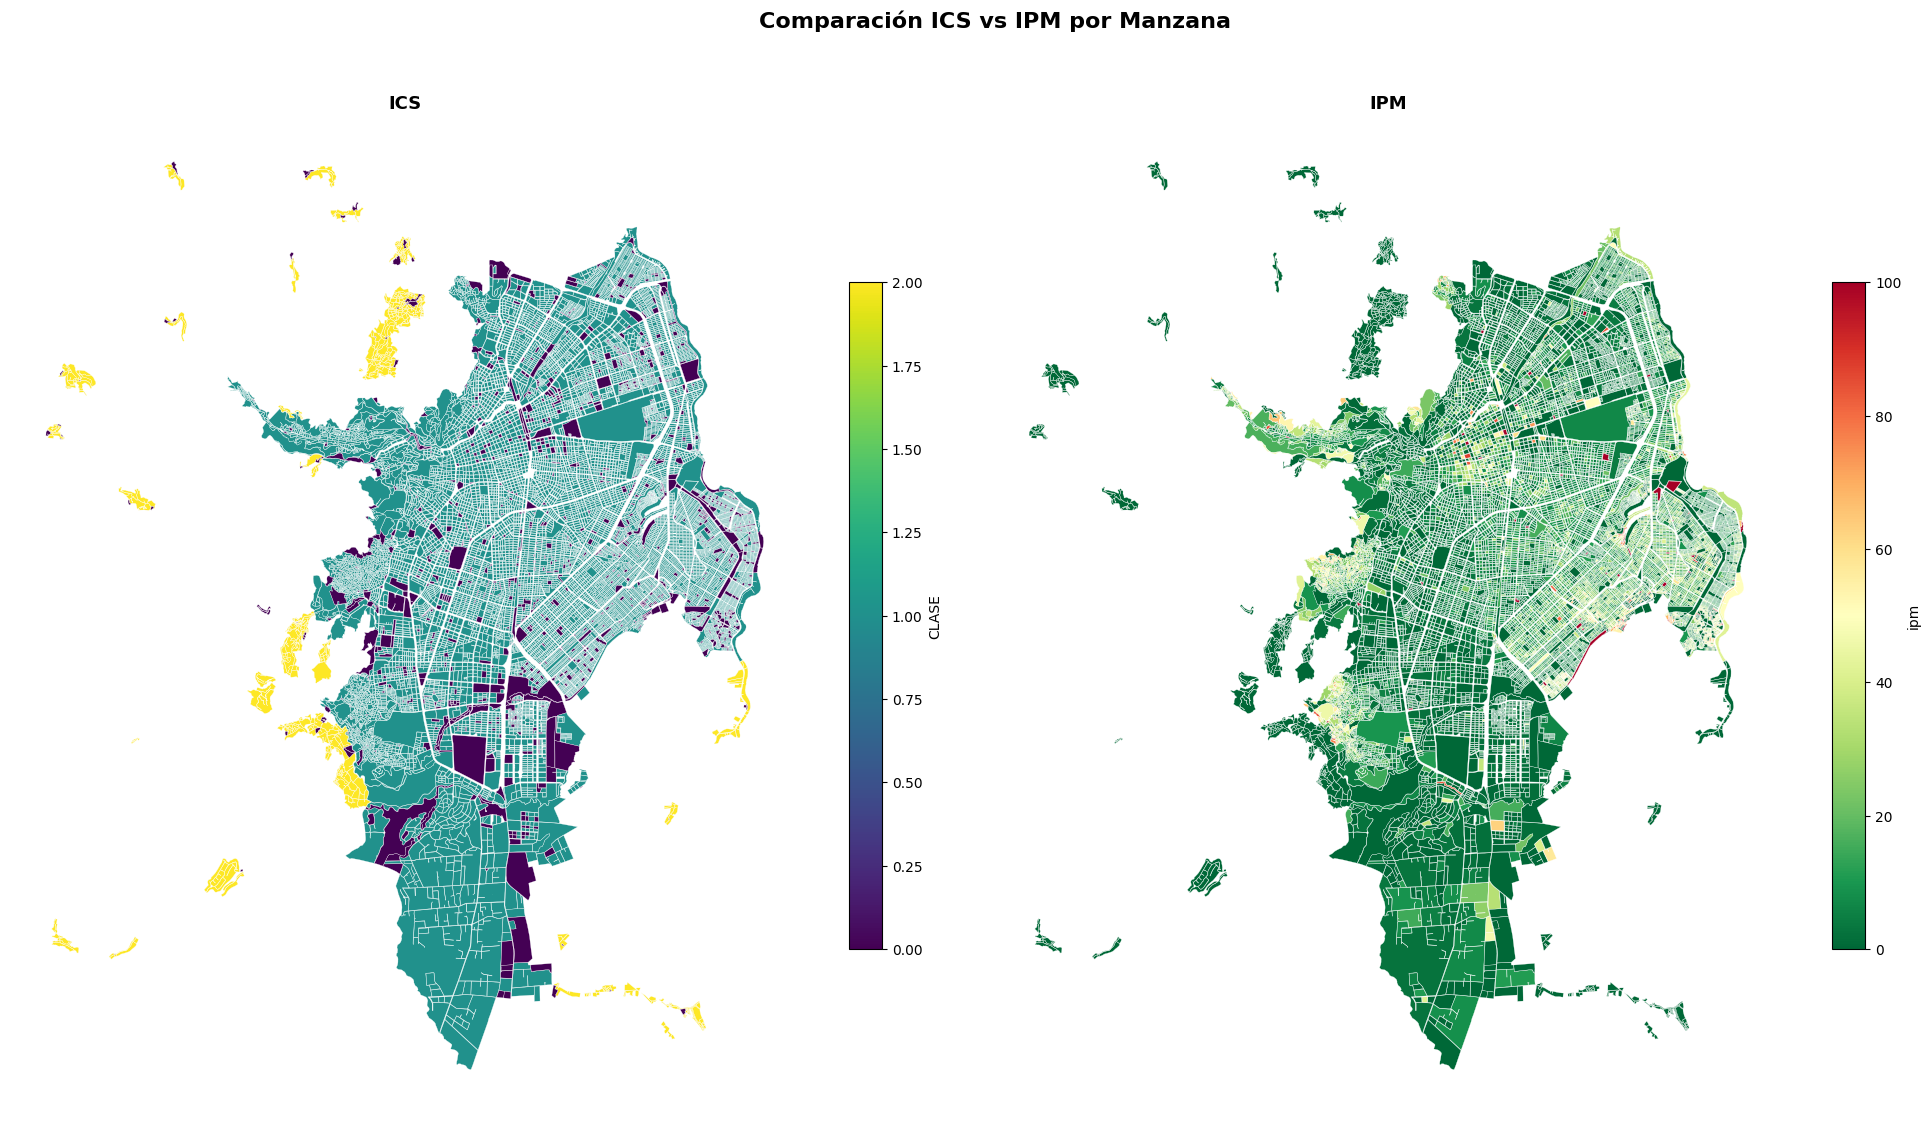

In [129]:
# @title 15. Mapas lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 14))

# ICS
if num_cols_ics:
    gdf_ics.plot(column=num_cols_ics[0], ax=ax1, legend=True,
                 cmap='viridis', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': num_cols_ics[0], 'shrink': 0.5})
    ax1.set_title('ICS', fontsize=13, fontweight='bold')
else:
    gdf_ics.plot(ax=ax1, color='#e0e0e0', edgecolor='#999999', linewidth=0.2)
    ax1.set_title('ICS (sin datos)', fontsize=13, fontweight='bold')
ax1.set_axis_off()

# IPM
if num_cols_ipm:
    gdf_ipm.plot(column=num_cols_ipm[0], ax=ax2, legend=True,
                 cmap='RdYlGn_r', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': num_cols_ipm[0], 'shrink': 0.5})
    ax2.set_title('IPM', fontsize=13, fontweight='bold')
else:
    gdf_ipm.plot(ax=ax2, color='#e0e0e0', edgecolor='#999999', linewidth=0.2)
    ax2.set_title('IPM (sin datos)', fontsize=13, fontweight='bold')
ax2.set_axis_off()

plt.suptitle('Comparación ICS vs IPM por Manzana', fontsize=16, fontweight='bold', y=0.92)
plt.tight_layout()
plt.show()


In [130]:
# @title 16. Estadísticas descriptivas
print('=== ICS ===')
if num_cols_ics:
    display(gdf_ics[num_cols_ics].describe())

print('\n=== IPM (shapefile) ===')
if num_cols_ipm:
    display(gdf_ipm[num_cols_ipm].describe())

# Diccionario de variables IPM
diccionario = {
    'analf_': 'Analfabetismo',
    'bajo_': 'Bajo logro educativo',
    'infancia_': 'Barreras primera infancia',
    'inasis_': 'Inasistencia escolar',
    'rezago_': 'Rezago escolar',
    'trab_infan_': 'Trabajo infantil',
    'depen_': 'Dependencia económica',
    'infor_': 'Informalidad',
    'salud_': 'Barreras de salud',
    'asegu_': 'Sin aseguramiento en salud',
    'haci_': 'Hacinamiento crítico',
    'pared_': 'Paredes precarias',
    'excre_': 'Eliminación inadecuada de excretas',
    'pisos_': 'Pisos precarios',
    'agua_': 'Sin acceso a agua mejorada'
}

# Cargar variables IPM desde Excel
xls = pd.ExcelFile(EXCEL_PATH)
sheets = [s for s in xls.sheet_names if s != 'Diccionario']
df_ipm_vars = None
for s in sheets:
    df_var = pd.read_excel(xls, s)
    col_name = df_var.columns[1]
    df_var = df_var.rename(columns={col_name: col_name + '_val'})
    df_var.columns = ['cod_mzn', col_name + '_val']
    if df_ipm_vars is None:
        df_ipm_vars = df_var
    else:
        df_ipm_vars = df_ipm_vars.merge(df_var, on='cod_mzn', how='outer')

val_cols = [c for c in df_ipm_vars.columns if c != 'cod_mzn']
print(f'Cargadas {len(val_cols)} variables IPM para {df_ipm_vars.shape[0]} manzanas')

print('\n=== Variables IPM (Excel) - Estadísticas ===')
display(df_ipm_vars[val_cols].describe().round(2))

# Top 5
means = df_ipm_vars[val_cols].mean().sort_values(ascending=False)
print('\n--- Top 5 variables IPM más críticas ---')
for var in means.head().index:
    label = diccionario.get(var.replace('_val',''), var)
    print(f'  {label}: {means[var]:.2f}%')
print(f'\nVariable más crítica: {diccionario.get(means.index[0].replace("_val",""), means.index[0])} ({means.iloc[0]:.2f}%)')


=== ICS ===


,CLASE,ics
count,15658.000000,15658.000000
mean,0.958807,29.804883
std,0.336837,17.176787
min,0.000000,0.000000
25%,1.000000,21.582804
50%,1.000000,29.552778
75%,1.000000,39.000000
max,2.000000,335.050018



=== IPM (shapefile) ===


,ipm,analf_,bajo_,infancia_,inasis_,rezago_,trab_infan,depen_,infor_,salud_,...,trab_infan_val,depen__val,infor__val,salud__val,asegu__val,haci__val,pared__val,excre__val,pisos__val,agua__val
count,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,...,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000
mean,11.691155,5.323659,31.614810,2.536535,3.892774,15.050798,0.795583,20.617596,71.284840,4.144026,...,0.795583,20.617596,71.284840,4.144026,18.730301,6.850543,0.840873,1.895432,0.430567,1.189167
std,14.733710,7.354803,23.431274,4.504190,6.590420,13.549174,2.683144,14.703059,29.337391,6.877965,...,2.683144,14.703059,29.337391,6.877965,12.264133,9.746928,4.837802,9.700233,2.796260,7.216322
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,11.363600,0.000000,0.000000,3.636400,0.000000,11.111100,70.895500,0.000000,...,0.000000,11.111100,70.895500,0.000000,11.023600,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.200000,2.792600,30.188700,0.000000,0.000000,12.903200,0.000000,19.613200,81.481500,0.597900,...,0.000000,19.613200,81.481500,0.597900,19.178100,3.092800,0.000000,0.000000,0.000000,0.000000
75%,17.100000,8.017650,48.780500,3.894850,5.633800,22.857100,0.000000,28.695700,88.235300,5.952400,...,0.000000,28.695700,88.235300,5.952400,26.427675,10.253775,0.000000,0.000000,0.000000,0.000000
max,100.000000,100.000000,100.000000,66.666700,80.000000,100.000000,80.000000,100.000000,100.000000,100.000000,...,80.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,80.000000,100.000000


Cargadas 15 variables IPM para 13687 manzanas

=== Variables IPM (Excel) - Estadísticas ===


,analf__val,bajo__val,infancia__val,inasis__val,rezago__val,trab_infan__val,depen__val,infor__val,salud__val,asegu__val,haci__val,pared__val,excre__val,pisos__val,agua__val
count,9512.00,13484.00,6487.00,7435.00,12210.00,2662.00,13415.00,13686.00,7932.00,13187.00,9228.00,1425.00,2008.00,1065.00,1511.00
mean,8.87,37.02,6.15,8.24,19.41,4.70,24.20,81.99,8.22,22.32,11.67,9.40,14.94,6.52,13.50
std,7.70,21.15,5.20,7.49,12.35,4.91,12.93,10.64,7.76,9.94,10.27,13.37,23.29,8.79,20.45
min,0.17,0.55,0.27,0.32,1.04,0.09,0.59,9.52,0.14,1.01,0.16,0.10,0.05,0.11,0.14
25%,3.70,19.88,2.86,3.42,10.05,1.99,15.28,76.19,3.12,15.56,4.52,1.74,1.68,1.56,1.71
50%,6.67,35.48,4.76,5.98,16.95,3.37,22.22,83.33,5.88,21.43,8.70,4.55,4.26,3.37,4.55
75%,11.65,51.95,7.69,10.34,26.03,5.67,30.59,89.19,10.78,27.84,15.50,11.11,16.07,7.79,14.91
max,100.00,100.00,66.67,80.00,100.00,80.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,80.00,100.00



--- Top 5 variables IPM más críticas ---
  Informalidad: 81.99%
  Bajo logro educativo: 37.02%
  Dependencia económica: 24.20%
  Sin aseguramiento en salud: 22.32%
  Rezago escolar: 19.41%

Variable más crítica: Informalidad (81.99%)


## Enriquecimiento geoespacial: Comunas y zonas de interés


In [131]:
# @title 17. Cargar GeoJSONs auxiliares (comunas, ITT territories)
gdf_comunas = gpd.read_file(PATH_COMUNAS)
print(f'Comunas: {gdf_comunas.shape[0]} geometrías')

# Cargar polígonos ITT dinámicamente
import glob
itt_files = glob.glob(os.path.join(PATH_ITT_DIR, 'poligono_*.geojson'))
gdf_itt = {}
for f in itt_files:
    name = os.path.basename(f).replace('poligono_', '').replace('.geojson', '').replace('_Buffer_100', '')
    gdf_itt[name] = gpd.read_file(f)
    print(f'Cargado {name}: {gdf_itt[name].shape[0]} geometrías')

# Asignar específicamente para compatibilidad con celdas posteriores
gdf_obrero = gdf_itt.get('Barrio_Obrero')
gdf_roosevelt = gdf_itt.get('Roosevelt')
gdf_oriente = gdf_itt.get('Oriente')


Comunas: 22 geometrías
Cargado ciudad_de_cali_T5: 1 geometrías
Cargado ciudad_de_cali_T3: 1 geometrías
Cargado ciudad_de_cali_T8: 1 geometrías


Cargado Barrio_Obrero: 1 geometrías
Cargado Roosevelt: 1 geometrías
Cargado ciudad_de_cali_T6: 1 geometrías
Cargado ciudad_de_cali_T1: 1 geometrías
Cargado ciudad_de_cali_T7: 1 geometrías
Cargado ciudad_de_cali_T4: 1 geometrías
Cargado ciudad_de_cali_T2: 1 geometrías
Cargado Oriente: 1 geometrías


In [132]:
# @title 18. Unificar CRS y asignar comuna por spatial join
crs_ref = gdf_ics.crs
print(f'CRS de referencia (ICS): {crs_ref}')

gdf_comunas_proj = gdf_comunas.to_crs(crs_ref)
gdf_ipm_proj = gdf_ipm.to_crs(crs_ref)

gdf_ics_con_comuna = gpd.sjoin(gdf_ics.copy().assign(geometry=gdf_ics.centroid), gdf_comunas_proj[['comuna', 'nombre', 'geometry']], how='left', predicate='within')
gdf_ics_con_comuna.geometry = gdf_ics.loc[gdf_ics_con_comuna.index].geometry

gdf_ipm_con_comuna = gpd.sjoin(gdf_ipm_proj.copy().assign(geometry=gdf_ipm_proj.centroid), gdf_comunas_proj[['comuna', 'nombre', 'geometry']], how='left', predicate='within')
gdf_ipm_con_comuna.geometry = gdf_ipm_proj.loc[gdf_ipm_con_comuna.index].geometry

comunas_ics = gdf_ics_con_comuna['comuna'].notna().sum()
comunas_ipm = gdf_ipm_con_comuna['comuna'].notna().sum()
print(f'Manzanas ICS con comuna asignada: {comunas_ics} / {len(gdf_ics_con_comuna)}')
print(f'Manzanas IPM con comuna asignada: {comunas_ipm} / {len(gdf_ipm_con_comuna)}')


CRS de referencia (ICS): EPSG:4326
Manzanas ICS con comuna asignada: 14457 / 15658
Manzanas IPM con comuna asignada: 14457 / 15658


/tmp/ipykernel_46877/1194185041.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ics_con_comuna = gpd.sjoin(gdf_ics.copy().assign(geometry=gdf_ics.centroid), gdf_comunas_proj[['comuna', 'nombre', 'geometry']], how='left', predicate='within')
/tmp/ipykernel_46877/1194185041.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_ipm_con_comuna = gpd.sjoin(gdf_ipm_proj.copy().assign(geometry=gdf_ipm_proj.centroid), gdf_comunas_proj[['comuna', 'nombre', 'geometry']], how='left', predicate='within')


In [133]:
# @title 19. Vista previa con comuna asignada
print('=== ICS con comuna ===')
display(gdf_ics_con_comuna.drop(columns='index_right', errors='ignore').head())

print('\n=== IPM con comuna ===')
display(gdf_ipm_con_comuna.drop(columns='index_right', errors='ignore').head())


=== ICS con comuna ===


,COD_MZN,CLASE,ZONA,cod_dane_a,ics,geometry,comuna,nombre
0,7600110000000001010101,1.0,Urbana,7600110000000001010101,32.883636,"MULTIPOLYGON (((-76.5736 3.45369, -76.57297 3....",1.0,Comuna 1
1,7600110000000001010102,1.0,Urbana,7600110000000001010102,26.022223,"MULTIPOLYGON (((-76.57208 3.45399, -76.57208 3...",1.0,Comuna 1
2,7600110000000001010111,1.0,Urbana,7600110000000001010111,30.111376,"MULTIPOLYGON (((-76.5747 3.45543, -76.57469 3....",1.0,Comuna 1
3,7600110000000001010112,1.0,Urbana,7600110000000001010112,29.542585,"MULTIPOLYGON (((-76.57574 3.45462, -76.5759 3....",1.0,Comuna 1
4,7600110000000001010113,1.0,Urbana,7600110000000001010113,33.991302,"MULTIPOLYGON (((-76.57596 3.45568, -76.57592 3...",1.0,Comuna 1



=== IPM con comuna ===


,cod_dpto,cod_mpio,cod_dane,ipm,oid_,cod_mzn,analf_,bajo_,infancia_,inasis_,...,infor__val,salud__val,asegu__val,haci__val,pared__val,excre__val,pisos__val,agua__val,comuna,nombre
0,76,76001,7600110000000001010101,5.7,0,7600110000000001010101,3.2520,34.1463,0.0000,0.0000,...,86.5854,1.6260,17.8862,7.7236,1.2195,0.0000,0.0000,3.6585,1.0,Comuna 1
1,76,76001,7600110000000001010102,8.9,1,7600110000000001010102,0.0000,37.7778,0.0000,10.0000,...,73.3333,4.4444,24.4444,8.8889,0.0000,1.1111,0.0000,0.0000,1.0,Comuna 1
2,76,76001,7600110000000001010111,6.3,2,7600110000000001010111,7.9365,48.1481,0.0000,0.0000,...,82.5397,15.3439,12.1693,10.5820,1.5873,0.5291,0.5291,0.5291,1.0,Comuna 1
3,76,76001,7600110000000001010112,10.5,3,7600110000000001010112,7.3930,30.7393,2.7237,5.4475,...,77.4319,2.3346,15.1751,10.8949,0.0000,0.0000,0.0000,0.0000,1.0,Comuna 1
4,76,76001,7600110000000001010113,13.0,4,7600110000000001010113,6.9565,26.9565,5.2174,0.0000,...,80.8696,0.0000,27.3913,9.5652,0.0000,0.0000,0.0000,0.0000,1.0,Comuna 1


In [134]:
# @title 20. Estadísticas de ICS, IPM y variables por comuna
print('=== ICS promedio por comuna ===')
ics_por_comuna = gdf_ics_con_comuna.groupby('nombre').agg(
    manzanas=('cod_dane_a', 'count'),
    ics_promedio=('ics', 'mean'),
    ics_min=('ics', 'min'),
    ics_max=('ics', 'max')
).round(2).sort_values('ics_promedio', ascending=False)
display(ics_por_comuna)

print('=== IPM global promedio por comuna ===')
ipm_por_comuna = gdf_ipm_con_comuna.groupby('nombre').agg(
    manzanas=('cod_dane', 'count'),
    ipm_promedio=('ipm', 'mean'),
    ipm_min=('ipm', 'min'),
    ipm_max=('ipm', 'max')
).round(2).sort_values('ipm_promedio')
display(ipm_por_comuna)

# Merge Excel vars con ICS para obtener geometrías
# Clave: quitar los 2 dígitos de comuna del código Excel
df_ipm_vars['COD_MZN'] = df_ipm_vars['cod_mzn'].astype(str).str[:6] + df_ipm_vars['cod_mzn'].astype(str).str[8:]

df_vars_geom = gdf_ics[['COD_MZN', 'geometry']].merge(
    df_ipm_vars, on='COD_MZN', how='inner')
gdf_vars = gpd.GeoDataFrame(df_vars_geom, crs=gdf_ics.crs)
print(f'\nMerge Excel+ICS: {len(gdf_vars)}/{len(df_ipm_vars)} manzanas con geometría')

# Spatial join con comunas usando centroide para asignacion unica
gdf_vars_comuna = gpd.sjoin(gdf_vars.copy().assign(geometry=gdf_vars.centroid), gdf_comunas_proj[['comuna', 'nombre', 'geometry']],
                             how='left', predicate='within')
gdf_vars_comuna.geometry = gdf_vars.loc[gdf_vars_comuna.index].geometry

# Top 3 variables IPM por comuna
print('\n=== Top 3 variables IPM por comuna ===')
comuna_stats = gdf_vars_comuna.groupby('nombre')[val_cols].mean().round(2)
top3_vars = means.head(3).index.tolist()
for var in top3_vars:
    label = diccionario.get(var.replace('_val',''), var)
    df_show = comuna_stats[var].sort_values(ascending=False).head(5).to_frame(label)
    print(f'\n{label} (top 5 comunas):')
    display(df_show)


=== ICS promedio por comuna ===


,manzanas,ics_promedio,ics_min,ics_max
nombre,,,,
Comuna 22,140,61.45,0.0,123.56
Comuna 19,668,44.82,0.0,97.10
Comuna 2,786,44.44,0.0,99.06
Comuna 17,759,43.69,0.0,98.00
Comuna 5,561,35.60,0.0,62.94
Comuna 10,548,34.92,0.0,75.46
Comuna 8,580,32.54,0.0,108.13
Comuna 12,323,31.43,0.0,87.28
Comuna 16,515,30.90,0.0,83.93


=== IPM global promedio por comuna ===


,manzanas,ipm_promedio,ipm_min,ipm_max
nombre,,,,
Comuna 19,775,3.27,0.0,100.0
Comuna 17,889,3.34,0.0,100.0
Comuna 22,159,4.10,0.0,83.3
Comuna 2,900,4.42,0.0,100.0
Comuna 5,635,4.80,0.0,83.3
Comuna 10,616,6.01,0.0,50.0
Comuna 8,640,8.56,0.0,100.0
Comuna 6,893,8.91,0.0,100.0
Comuna 4,537,9.30,0.0,100.0



Merge Excel+ICS: 13614/13687 manzanas con geometría

=== Top 3 variables IPM por comuna ===

Informalidad (top 5 comunas):


...

,Informalidad
nombre,
Comuna 20,87.83
Comuna 9,87.04
Comuna 15,86.89
Comuna 13,86.69
Comuna 14,86.51



Bajo logro educativo (top 5 comunas):


,Bajo logro educativo
nombre,
Comuna 20,62.09
Comuna 14,51.87
Comuna 1,49.48
Comuna 13,48.64
Comuna 15,46.05



Dependencia económica (top 5 comunas):


,Dependencia económica
nombre,
Comuna 15,31.16
Comuna 14,30.82
Comuna 21,30.56
Comuna 13,28.87
Comuna 20,28.19


In [135]:
# @title 21. Identificar manzanas en todas las zonas ITT (Dinámico)
gdf_itt_proj = {}
for name, poly in gdf_itt.items():
    # Proyectar al CRS de referencia (ICS)
    gdf_itt_proj[name] = poly.to_crs(crs_ref)
    
    # Identificar manzanas dentro de la zona (en ICS e IPM)
    col_name = f'en_{name.lower()}'
    
    # Usar .index.isin() para evitar errores de reindexación con duplicados en el join
    # Seleccion por centroide para garantizar >50% de area en la zona
    join_ics = gpd.sjoin(gdf_ics.copy().assign(geometry=gdf_ics.centroid), gdf_itt_proj[name], how='inner', predicate='within')
    gdf_ics[col_name] = gdf_ics.index.isin(join_ics.index)
    
    join_ipm = gpd.sjoin(gdf_ipm_proj.copy().assign(geometry=gdf_ipm_proj.centroid), gdf_itt_proj[name], how='inner', predicate='within')
    gdf_ipm[col_name] = gdf_ipm.index.isin(join_ipm.index)
    
    count = gdf_ics[col_name].sum()
    print(f'Zona {name:.<30} {count} manzanas encontradas')

# Alias para compatibilidad con celdas antiguas
gdf_obrero_proj = gdf_itt_proj.get('Barrio_Obrero')
gdf_roosevelt_proj = gdf_itt_proj.get('Roosevelt')


/tmp/ipykernel_46877/2613999817.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ics = gpd.sjoin(gdf_ics.copy().assign(geometry=gdf_ics.centroid), gdf_itt_proj[name], how='inner', predicate='within')
/tmp/ipykernel_46877/2613999817.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ipm = gpd.sjoin(gdf_ipm_proj.copy().assign(geometry=gdf_ipm_proj.centroid), gdf_itt_proj[name], how='inner', predicate='within')


Zona ciudad_de_cali_T5............. 67 manzanas encontradas


/tmp/ipykernel_46877/2613999817.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ics = gpd.sjoin(gdf_ics.copy().assign(geometry=gdf_ics.centroid), gdf_itt_proj[name], how='inner', predicate='within')
/tmp/ipykernel_46877/2613999817.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ipm = gpd.sjoin(gdf_ipm_proj.copy().assign(geometry=gdf_ipm_proj.centroid), gdf_itt_proj[name], how='inner', predicate='within')


Zona ciudad_de_cali_T3............. 90 manzanas encontradas


/tmp/ipykernel_46877/2613999817.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ics = gpd.sjoin(gdf_ics.copy().assign(geometry=gdf_ics.centroid), gdf_itt_proj[name], how='inner', predicate='within')
/tmp/ipykernel_46877/2613999817.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ipm = gpd.sjoin(gdf_ipm_proj.copy().assign(geometry=gdf_ipm_proj.centroid), gdf_itt_proj[name], how='inner', predicate='within')


...

Zona ciudad_de_cali_T4............. 110 manzanas encontradas


/tmp/ipykernel_46877/2613999817.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ics = gpd.sjoin(gdf_ics.copy().assign(geometry=gdf_ics.centroid), gdf_itt_proj[name], how='inner', predicate='within')
/tmp/ipykernel_46877/2613999817.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ipm = gpd.sjoin(gdf_ipm_proj.copy().assign(geometry=gdf_ipm_proj.centroid), gdf_itt_proj[name], how='inner', predicate='within')


Zona ciudad_de_cali_T2............. 41 manzanas encontradas


/tmp/ipykernel_46877/2613999817.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ics = gpd.sjoin(gdf_ics.copy().assign(geometry=gdf_ics.centroid), gdf_itt_proj[name], how='inner', predicate='within')
/tmp/ipykernel_46877/2613999817.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_ipm = gpd.sjoin(gdf_ipm_proj.copy().assign(geometry=gdf_ipm_proj.centroid), gdf_itt_proj[name], how='inner', predicate='within')


Zona Oriente....................... 1068 manzanas encontradas


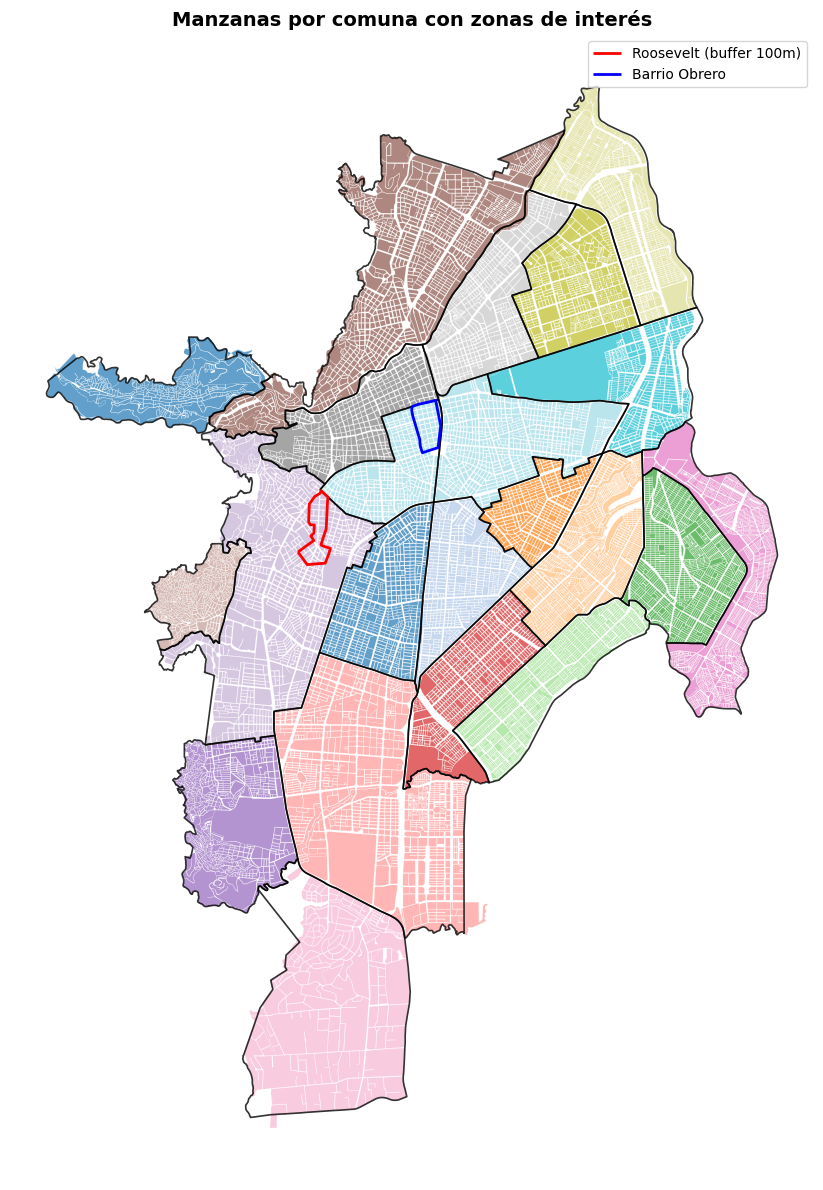

In [136]:
# @title 22. Mapa - Manzanas por comuna con zonas de inter\u00e9s
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_ics_con_comuna.plot(column='nombre', ax=ax, legend=True,
                         cmap='tab20', edgecolor='white', linewidth=0.1, alpha=0.7,
                         legend_kwds={'title': 'Comuna', 'loc': 'upper left', 'fontsize': 8})

gdf_comunas_proj.boundary.plot(ax=ax, color='black', linewidth=1.2, alpha=0.8)
gdf_roosevelt_proj.boundary.plot(ax=ax, color='red', linewidth=2, label='Roosevelt (buffer 100m)')
gdf_obrero_proj.boundary.plot(ax=ax, color='blue', linewidth=2, label='Barrio Obrero')

ax.set_title('Manzanas por comuna con zonas de inter\u00e9s', fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()


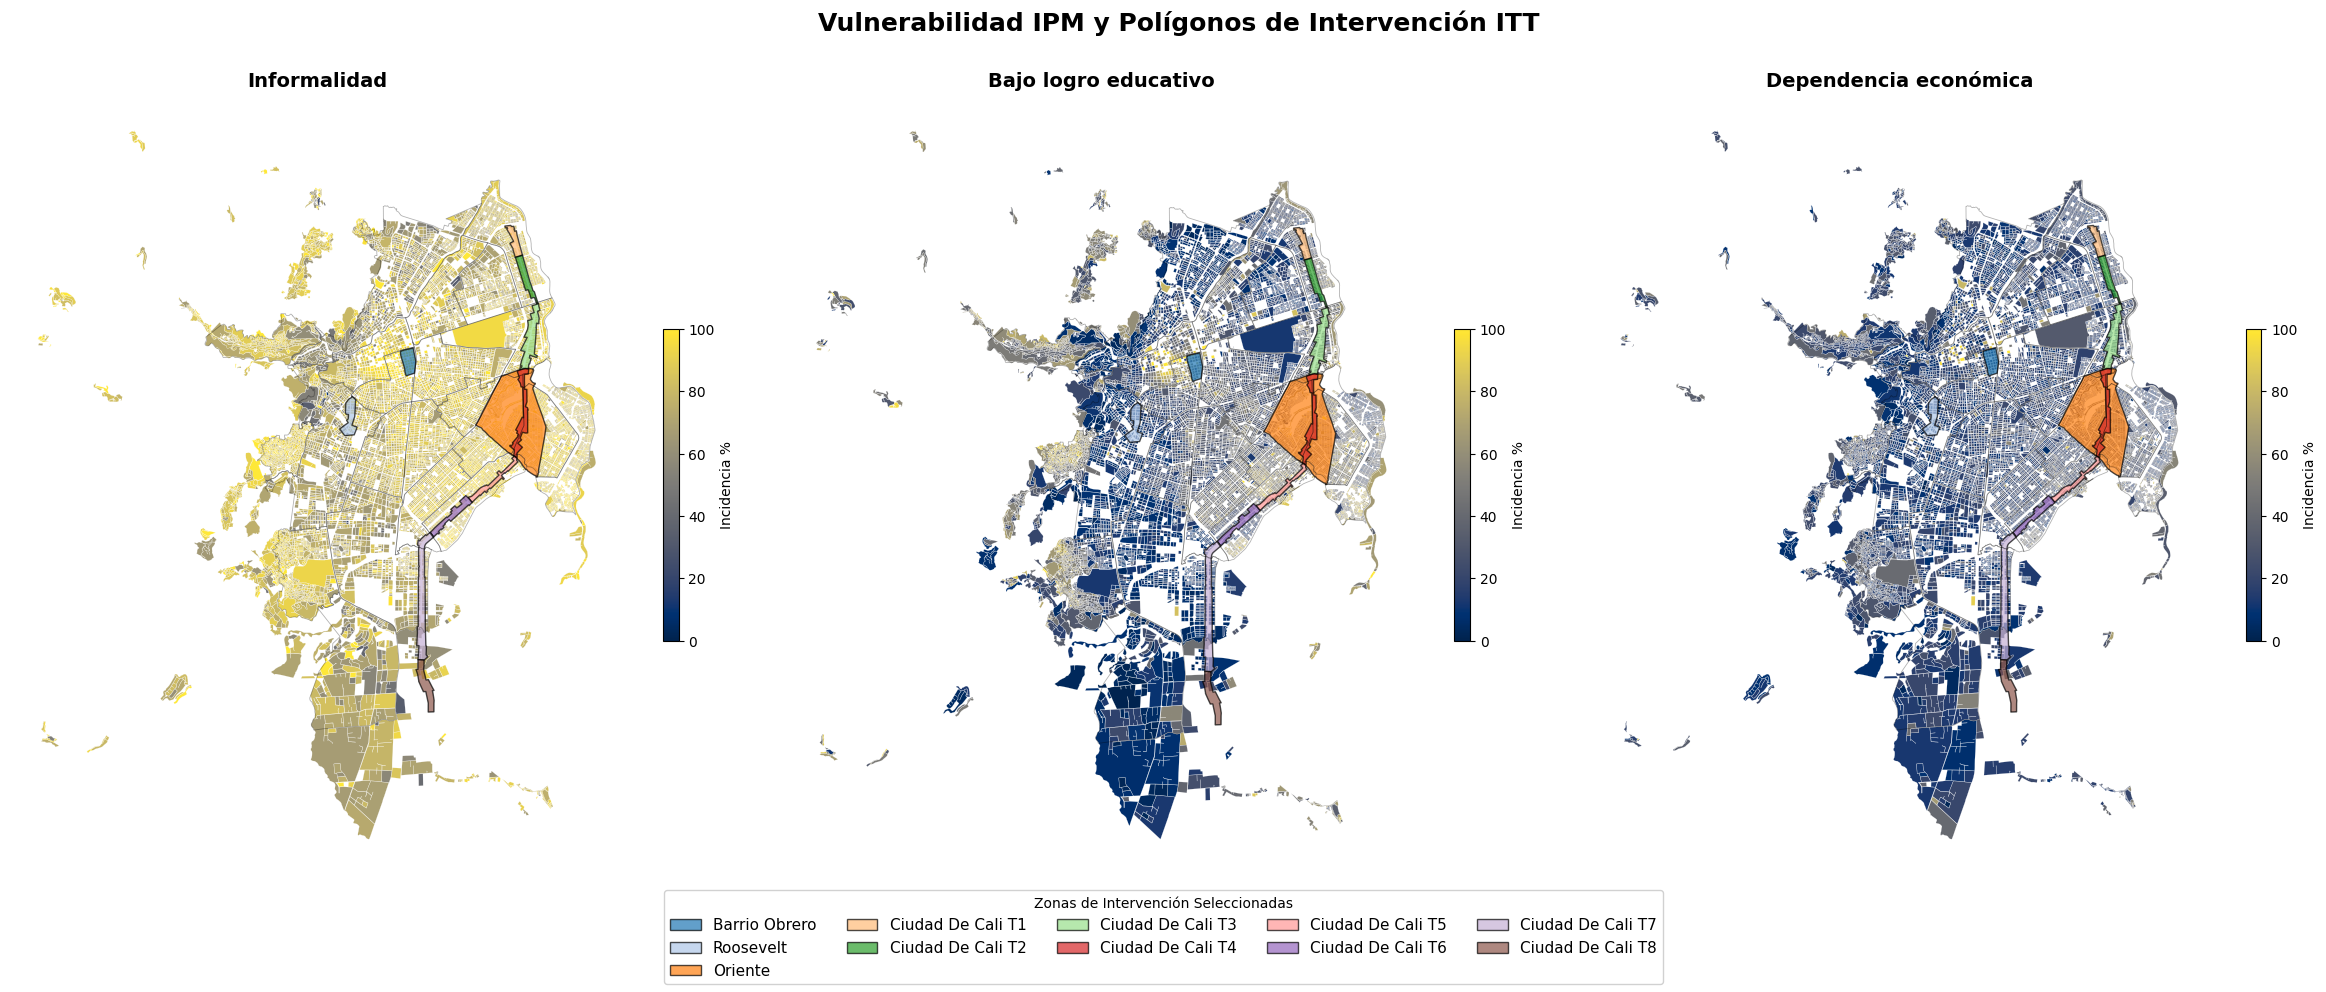

In [137]:
# @title 23. Mapa - Variables IPM más Críticas con Filtro de Tramos
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import geopandas as gpd
import pandas as pd

# --- INICIALIZACIÓN ABSOLUTA DE SEGURIDAD ---
try:
    # Intentamos asegurar que gdf_vars exista y sea un GeoDataFrame
    if 'gdf_vars' not in locals() and 'gdf_vars' not in globals():
        print("Definiendo gdf_vars desde gdf_ipm...")
        gdf_vars = gdf_ipm
    
    # Aseguramos que 'means' tenga datos para el top 3
    if 'means' not in locals() and 'means' not in globals():
        print("Calculando medias de incidencia...")
        inc_cols = [c for c in gdf_vars.columns if c.endswith('_') or c.endswith('_val')]
        means = gdf_vars[inc_cols].mean().sort_values(ascending=False)
        
    # Diccionario básico si falta
    if 'diccionario' not in locals() and 'diccionario' not in globals():
        diccionario = {}
except NameError as e:
    print(f"Error: Los datos maestros no están cargados. Por favor corre la celda 6. Detalle: {e}")
    raise e
# ---------------------------------------------

# -------------------------------------------------------------------------
# AQUÍ PUEDES ACTIVAR O DESACTIVAR LOS POLÍGONOS A MOSTRAR.
# Edita la lista a continuación, quitando o poniendo los nombres de los tramos.
# Nombres disponibles: 'Barrio_Obrero', 'Roosevelt', 'Oriente', 
# 'ciudad_de_cali_T1', 'ciudad_de_cali_T2', ..., 'ciudad_de_cali_T8'
# -------------------------------------------------------------------------
ZONAS_VISIBLES = [
    'Barrio_Obrero', 
    'Roosevelt', 'Oriente',
    'ciudad_de_cali_T1','ciudad_de_cali_T2','ciudad_de_cali_T3', 'ciudad_de_cali_T4', 'ciudad_de_cali_T5', 
    'ciudad_de_cali_T6', 'ciudad_de_cali_T7', 'ciudad_de_cali_T8'
]

# Mapa de las 3 variables IPM con mayor incidencia
top3_vars = means.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# Paleta de colores optimizada (colorblind friendly)
cmap_tramos = plt.get_cmap('tab20')

for idx_ax, (ax, var) in enumerate(zip(axes, top3_vars)):
    label = diccionario.get(var.replace('_val',''), var)
    
    # Capa base: Variables IPM
    gdf_vars.plot(column=var, ax=ax, legend=True,
                 cmap='cividis', edgecolor='white', linewidth=0.1,
                 legend_kwds={'shrink': 0.4, 'label': 'Incidencia %'},
                 vmin=0, vmax=100)
    
    # Capa 2: Comunas (transparente)
    gdf_comunas_proj.boundary.plot(ax=ax, color='black', linewidth=0.6, alpha=0.3)
    
    # Capa 3: Polígonos ITT Seleccionados (Relleno sólido)
    for i, zona_name in enumerate(ZONAS_VISIBLES):
        if zona_name in gdf_itt:
            color_z = cmap_tramos(i % 20)
            gdf_itt[zona_name].to_crs(gdf_vars.crs).plot(
                ax=ax, color=color_z, alpha=0.7, edgecolor='black', linewidth=1)
            
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_axis_off()

# Leyenda dinámica de zonas
legend_patches = []
for i, zona_name in enumerate(ZONAS_VISIBLES):
    if zona_name in gdf_itt:
        legend_patches.append(Patch(facecolor=cmap_tramos(i % 20), 
                                    edgecolor='black', alpha=0.7, 
                                    label=zona_name.replace('_', ' ').title()))

fig.legend(handles=legend_patches, loc='lower center', ncol=5, 
           fontsize=11, framealpha=0.9, title="Zonas de Intervención Seleccionadas")

plt.suptitle('Vulnerabilidad IPM y Polígonos de Intervención ITT', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()


In [138]:
# @title 24. Filtrar variables IPM por zona
# Spatial join de variables IPM con cada zona de interés
gdf_vars_obrero = gpd.sjoin(gdf_vars.copy().assign(geometry=gdf_vars.centroid), gdf_obrero_proj, how='inner', predicate='within')
gdf_vars_obrero.geometry = gdf_vars.loc[gdf_vars_obrero.index].geometry

gdf_vars_roosevelt = gpd.sjoin(gdf_vars.copy().assign(geometry=gdf_vars.centroid), gdf_roosevelt_proj, how='inner', predicate='within')
gdf_vars_roosevelt.geometry = gdf_vars.loc[gdf_vars_roosevelt.index].geometry

gdf_vars_oriente = gpd.sjoin(gdf_vars.copy().assign(geometry=gdf_vars.centroid), gdf_itt_proj['Oriente'], how='inner', predicate='within')
gdf_vars_oriente.geometry = gdf_vars.loc[gdf_vars_oriente.index].geometry
gdf_vars_cali_tramos = {}
for i in range(1, 9):
    key = f'ciudad_de_cali_T{i}'
    # Seleccion por centroide para cada tramo
    join_res = gpd.sjoin(gdf_vars.copy().assign(geometry=gdf_vars.centroid), gdf_itt_proj[key], how='inner', predicate='within')
    join_res.geometry = gdf_vars.loc[join_res.index].geometry
    gdf_vars_cali_tramos[key] = join_res

print(f'Manzanas con vars IPM en Barrio Obrero: {len(gdf_vars_obrero)}')
print(f'Manzanas con vars IPM en Roosevelt: {len(gdf_vars_roosevelt)}')
print(f'Manzanas con vars IPM en Oriente: {len(gdf_vars_oriente)}')
for i in range(1, 9):
    key = f'ciudad_de_cali_T{i}'
    print(f'Manzanas con vars IPM en Ciudad de Cali {key}: {len(gdf_vars_cali_tramos[key])}')

# Consolidado Ciudad de Cali (todos los tramos)
gdf_vars_cali = pd.concat(gdf_vars_cali_tramos.values())
gdf_vars_cali = gdf_vars_cali[~gdf_vars_cali.index.duplicated(keep='first')]
print(f'\nManzanas con vars IPM en Ciudad de Cali (consolidado): {len(gdf_vars_cali)}')

# Promedio por zona
def print_top5(gdf_vars_zona, label):
    means = gdf_vars_zona[val_cols].mean().sort_values(ascending=False)
    print(f'\n--- Top 5 {label} ---')
    for v in means.head().index:
        lbl = diccionario.get(v.replace('_val',''), v)
        print(f'  {lbl}: {means[v]:.2f}%')

print_top5(gdf_vars_obrero, 'Barrio Obrero')
print_top5(gdf_vars_roosevelt, 'Roosevelt')
print_top5(gdf_vars_oriente, 'Oriente')
print_top5(gdf_vars_cali, 'Ciudad de Cali (consolidado)')
for i in range(1, 9):
    key = f'ciudad_de_cali_T{i}'
    print_top5(gdf_vars_cali_tramos[key], f'Ciudad de Cali T{i}')


/tmp/ipykernel_46877/2853502305.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_vars_obrero = gpd.sjoin(gdf_vars.copy().assign(geometry=gdf_vars.centroid), gdf_obrero_proj, how='inner', predicate='within')
/tmp/ipykernel_46877/2853502305.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_vars_roosevelt = gpd.sjoin(gdf_vars.copy().assign(geometry=gdf_vars.centroid), gdf_roosevelt_proj, how='inner', predicate='within')
/tmp/ipykernel_46877/2853502305.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_vars_oriente = gpd.sjoin(gdf_vars.copy().assign(geometr

Manzanas con vars IPM en Barrio Obrero: 43
Manzanas con vars IPM en Roosevelt: 34
Manzanas con vars IPM en Oriente: 945
Manzanas con vars IPM en Ciudad de Cali ciudad_de_cali_T1: 37
Manzanas con vars IPM en Ciudad de Cali ciudad_de_cali_T2: 41
Manzanas con vars IPM en Ciudad de Cali ciudad_de_cali_T3: 78
Manzanas con vars IPM en Ciudad de Cali ciudad_de_cali_T4: 104
Manzanas con vars IPM en Ciudad de Cali ciudad_de_cali_T5: 59
Manzanas con vars IPM en Ciudad de Cali ciudad_de_cali_T6: 88
Manzanas con vars IPM en Ciudad de Cali ciudad_de_cali_T7: 54
Manzanas con vars IPM en Ciudad de Cali ciudad_de_cali_T8: 1

Manzanas con vars IPM en Ciudad de Cali (consolidado): 462

--- Top 5 Barrio Obrero ---
  Informalidad: 92.73%
  Bajo logro educativo: 54.19%
  Dependencia económica: 27.05%
  Rezago escolar: 21.13%
  Sin aseguramiento en salud: 19.19%

--- Top 5 Roosevelt ---
  Informalidad: 74.36%
  Trabajo infantil: 31.25%
  Sin aseguramiento en salud: 22.05%
  Dependencia económica: 19.09%
  B

/tmp/ipykernel_46877/2853502305.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  join_res = gpd.sjoin(gdf_vars.copy().assign(geometry=gdf_vars.centroid), gdf_itt_proj[key], how='inner', predicate='within')


## Análisis Territorial Comparativo (Títulos 25 a 31)


/tmp/ipykernel_46877/1738963960.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid),
/tmp/ipykernel_46877/1738963960.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid),
/tmp/ipykernel_46877/1738963960.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid),
/tmp/ipykernel_46877/1738963960.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' 

IPM promedio por zona (desagregado):


,Zona,IPM Global,Tipo
0,Barrio Obrero,13.6,Intervencion
1,Roosevelt,3.9,Intervencion
2,Oriente (Pulmon de Oriente),17.7,Intervencion
3,Ciudad de Cali,12.7,Intervencion
4,Cali Expansion,1.0,Linea base
5,Cali Urbana,14.4,Linea base
6,Cali (sin zona),2.5,Linea base


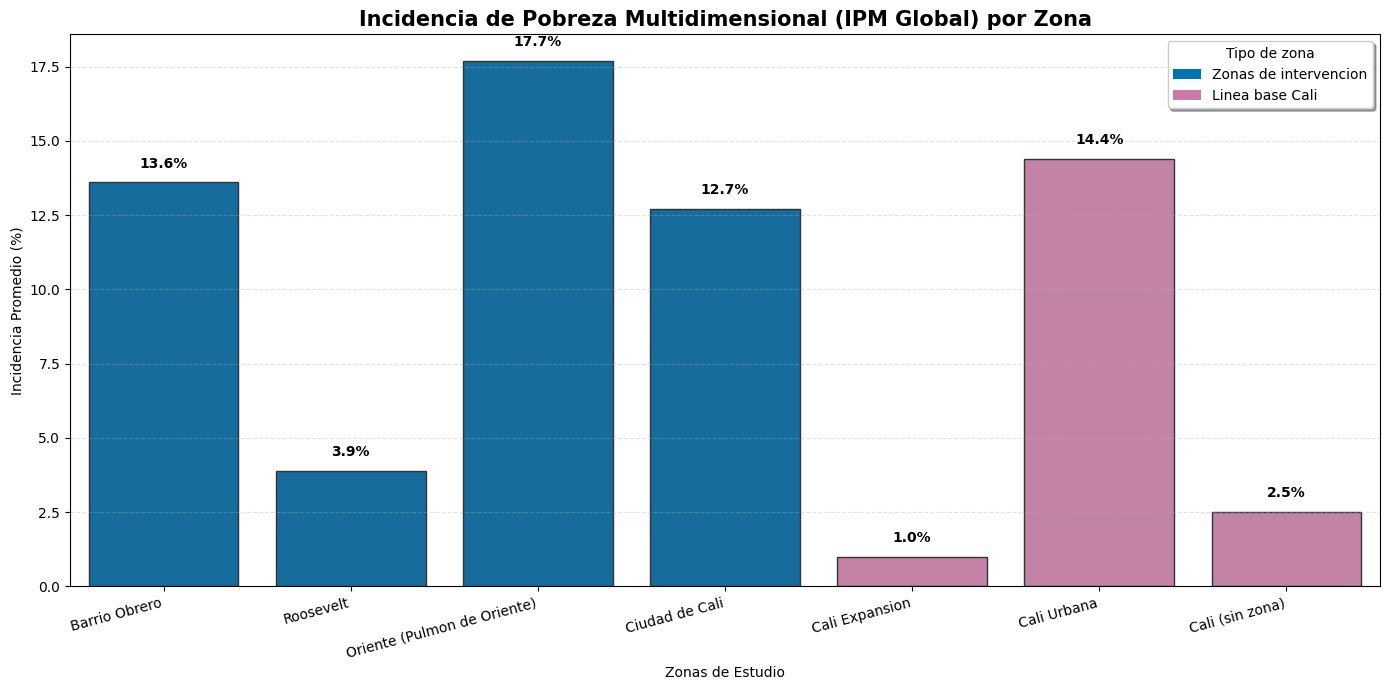

/tmp/ipykernel_46877/1738963960.py:92: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid),
/tmp/ipykernel_46877/1738963960.py:92: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid),
/tmp/ipykernel_46877/1738963960.py:92: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid),
/tmp/ipykernel_46877/1738963960.py:92: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' 

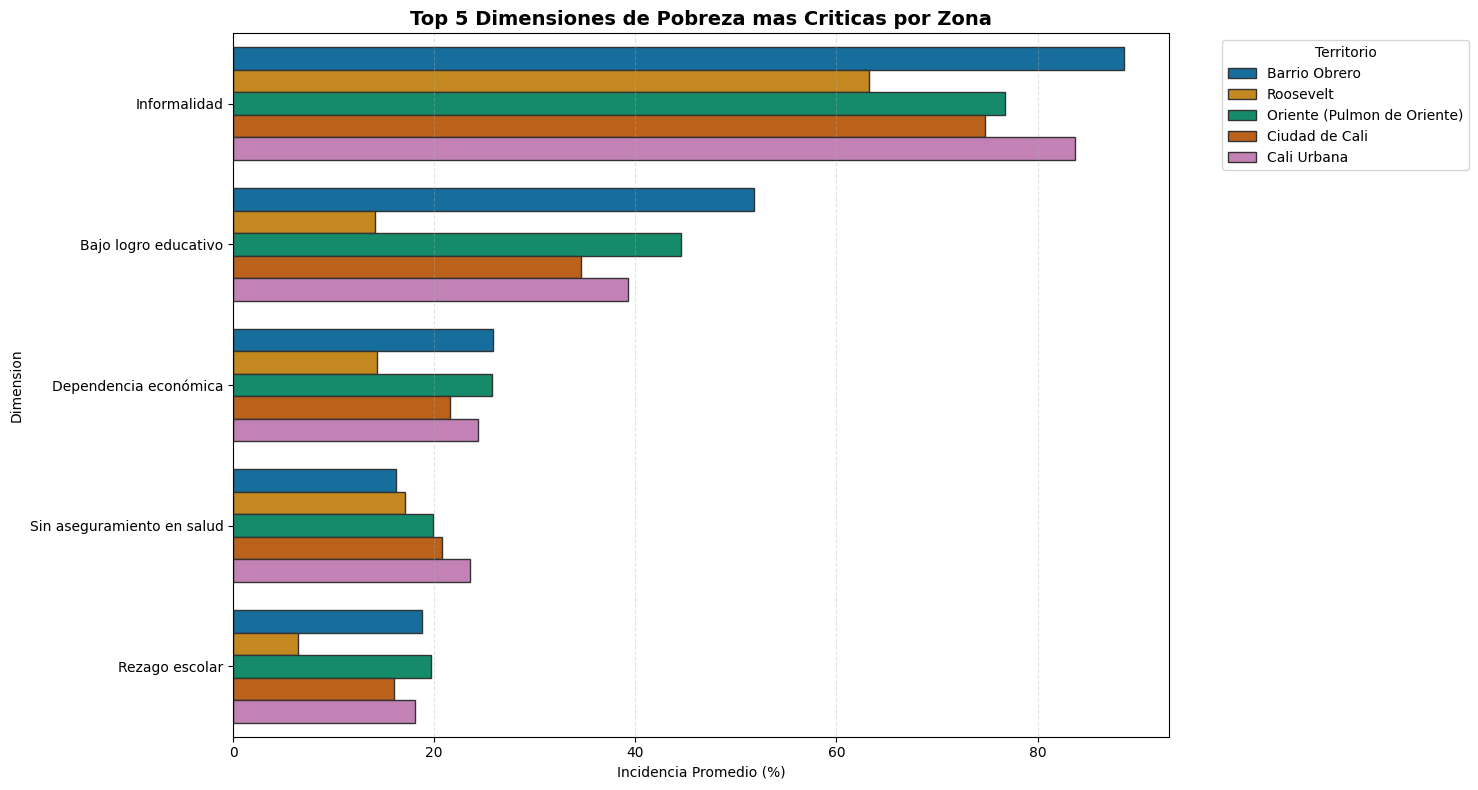

In [139]:
# @title 25. Grafico - Comparativa de Pobreza Multidimensional (IPM) por Zona
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# 1. Unificacion de Ciudad de Cali como Referente (Dissolve)
tramos_cali = [gdf_itt_proj[f"ciudad_de_cali_T{i}"] for i in range(1,9) if f"ciudad_de_cali_T{i}" in gdf_itt_proj]
gdf_cali_referente = pd.concat(tramos_cali).dissolve() if tramos_cali else None

# 2. Estructura de las Zonas de Analisis (intervencion)
zonas_reporte = {
    "Barrio Obrero": gdf_itt_proj.get("Barrio_Obrero"),
    "Roosevelt": gdf_itt_proj.get("Roosevelt"),
    "Oriente (Pulmon de Oriente)": gdf_itt_proj.get("Oriente"),
    "Ciudad de Cali": gdf_cali_referente
}

# 3. Fusionar ZONA (Urbana/Rural) de ICS en IPM para desagregar Cali
# gdf_ics tiene columna ZONA, gdf_ipm tiene cod_dane
cod_merge = gdf_ics[["cod_dane_a", "ZONA"]].drop_duplicates(subset="cod_dane_a")
gdf_ipm_con_zona = gdf_ipm.merge(cod_merge, left_on="cod_dane", right_on="cod_dane_a", how="left")

# 4. Calcular IPM global por zona de intervencion
ipm_promedios = []
for nom, poly in zonas_reporte.items():
    if poly is not None:
        # Seleccion limpia por centroide (>50% area)
        mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid), 
                             poly.to_crs(gdf_ipm.crs), how="inner", predicate="within")
        mzn_zona.geometry = gdf_ipm.loc[mzn_zona.index].geometry
        ipm_promedios.append({"Zona": nom, "IPM Global": mzn_zona["ipm"].mean(), "Tipo": "Intervencion"})

# 5. Calcular IPM de Cali desagregado por ZONA (Urbana, Rural, Expansion)
# Usamos spatial join para filtrar solo Cali, luego agrupamos por ZONA
if gdf_cali_referente is not None:
    mzn_cali = gpd.sjoin(gdf_ipm_con_zona, gdf_cali_referente.to_crs(gdf_ipm.crs), how="inner", predicate="within")
    mzn_cali = mzn_cali.drop(columns=[c for c in mzn_cali.columns if c.startswith("index_")], errors="ignore")
    # Agrupar por ZONA
    for zona_val, grp in mzn_cali.groupby("ZONA", dropna=False):
        zona_label = f"Cali {zona_val}" if pd.notna(zona_val) else "Cali (sin zona)"
        ipm_promedios.append({"Zona": zona_label, "IPM Global": grp["ipm"].mean(), "Tipo": "Linea base"})
else:
    # Fallback: agrupar directamente desde gdf_ipm_con_zona sin filtro espacial
    for zona_val, grp in gdf_ipm_con_zona.groupby("ZONA", dropna=False):
        zona_label = f"Cali {zona_val}" if pd.notna(zona_val) else "Cali (sin zona)"
        ipm_promedios.append({"Zona": zona_label, "IPM Global": grp["ipm"].mean(), "Tipo": "Linea base"})

df_ipm_comp = pd.DataFrame(ipm_promedios).round(1)
print("IPM promedio por zona (desagregado):")
display(df_ipm_comp)

# 6. Grafico Principal con diferenciacion visual
PALETA_TIPO = {
    "Intervencion": "#0072B2",
    "Linea base": "#CC79A7"
}
ORDEN_ZONAS = df_ipm_comp["Zona"].tolist()

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=df_ipm_comp, x="Zona", y="IPM Global", hue="Tipo",
    palette=PALETA_TIPO, edgecolor="#333333", ax=ax, dodge=False
)
ax.set_title("Incidencia de Pobreza Multidimensional (IPM Global) por Zona", fontsize=15, fontweight="bold")
ax.set_ylabel("Incidencia Promedio (%)")
ax.set_xlabel("Zonas de Estudio")
ax.grid(axis="y", linestyle="--", alpha=0.35)

for i, v in enumerate(df_ipm_comp["IPM Global"]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=10)

# Leyenda personalizada
from matplotlib.patches import Patch
leyenda_handles = [
    Patch(facecolor="#0072B2", label="Zonas de intervencion"),
    Patch(facecolor="#CC79A7", label="Linea base Cali"),
]
ax.legend(handles=leyenda_handles, title="Tipo de zona", frameon=True, shadow=True)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# 7. Analisis Complementario: Top 5 de Variables
val_cols = [c for c in gdf_ipm.columns if c.endswith("_val")]
top5_vars = gdf_ipm[val_cols].mean().nlargest(5).index
top5_data = []

for nom, poly in zonas_reporte.items():
    if poly is not None:
        # Seleccion limpia por centroide (>50% area)
        mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid), 
                             poly.to_crs(gdf_ipm.crs), how="inner", predicate="within")
        mzn_zona.geometry = gdf_ipm.loc[mzn_zona.index].geometry
        m_inc = mzn_zona[top5_vars].mean().to_frame("Incidencia")
        m_inc["Dimension"] = [diccionario.get(v.replace("_val",""), v) for v in m_inc.index]
        m_inc["Zona"] = nom
        top5_data.append(m_inc)

# Agregar top5 para Cali Urbana como referencia
if gdf_cali_referente is not None:
    mzn_cali_urb = gpd.sjoin(gdf_ipm_con_zona[gdf_ipm_con_zona["ZONA"] == "Urbana"],
                               gdf_cali_referente.to_crs(gdf_ipm.crs), how="inner", predicate="within")
    mzn_cali_urb = mzn_cali_urb.drop(columns=[c for c in mzn_cali_urb.columns if c.startswith("index_")], errors="ignore")
    if len(mzn_cali_urb) > 0:
        m_inc_urb = mzn_cali_urb[top5_vars].mean().to_frame("Incidencia")
        m_inc_urb["Dimension"] = [diccionario.get(v.replace("_val",""), v) for v in m_inc_urb.index]
        m_inc_urb["Zona"] = "Cali Urbana"
        top5_data.append(m_inc_urb)

df_plot_top5 = pd.concat(top5_data).round(1)

fig, ax = plt.subplots(figsize=(15, 8))
sns.barplot(data=df_plot_top5, x="Incidencia", y="Dimension", hue="Zona", palette="colorblind", edgecolor="#333333", ax=ax)
ax.set_title("Top 5 Dimensiones de Pobreza mas Criticas por Zona", fontsize=14, fontweight="bold")
ax.set_xlabel("Incidencia Promedio (%)")
ax.legend(title="Territorio", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


## Mapas Individuales de Pobreza Multidimensional
Cartografía individual con Zoom Dinámico y fondo urbano atenuado.


/tmp/ipykernel_46877/1704650157.py:74: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid), poly, how="inner", predicate="within")


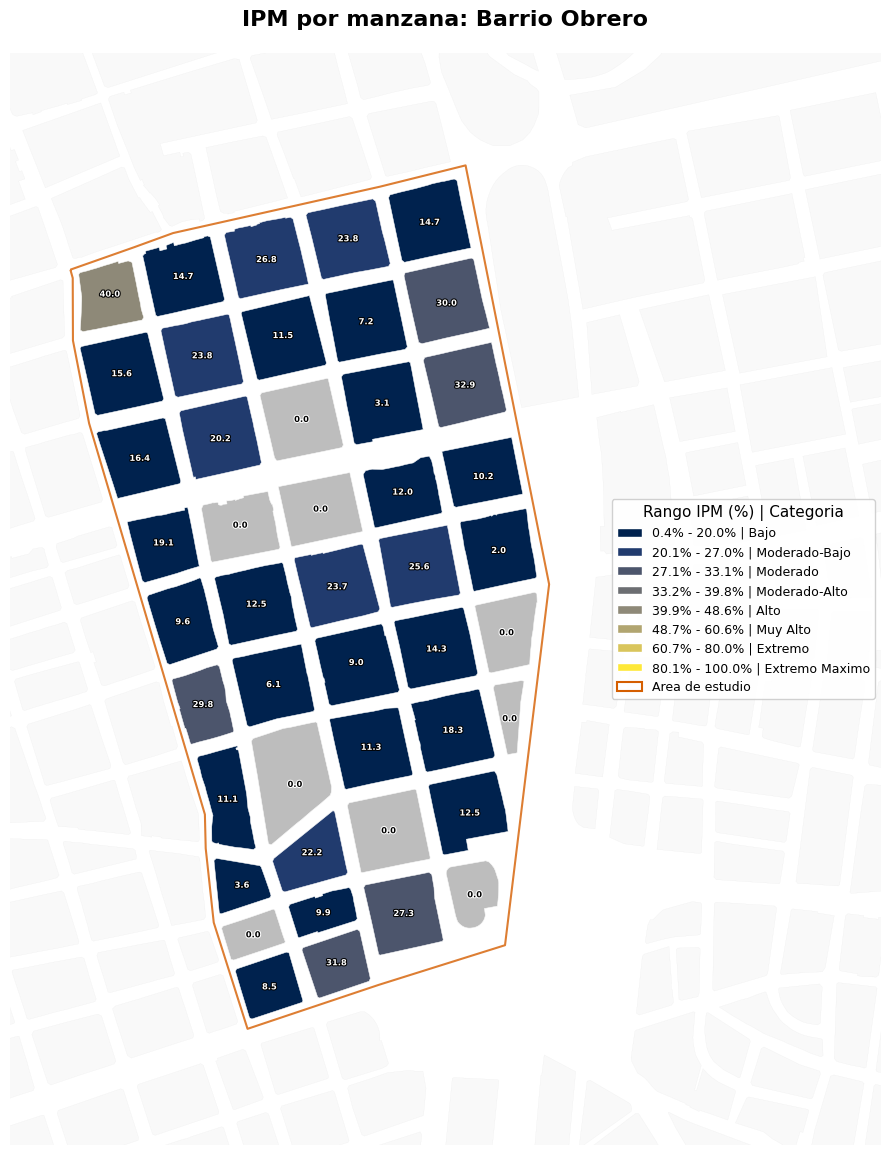

/tmp/ipykernel_46877/1704650157.py:74: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid), poly, how="inner", predicate="within")


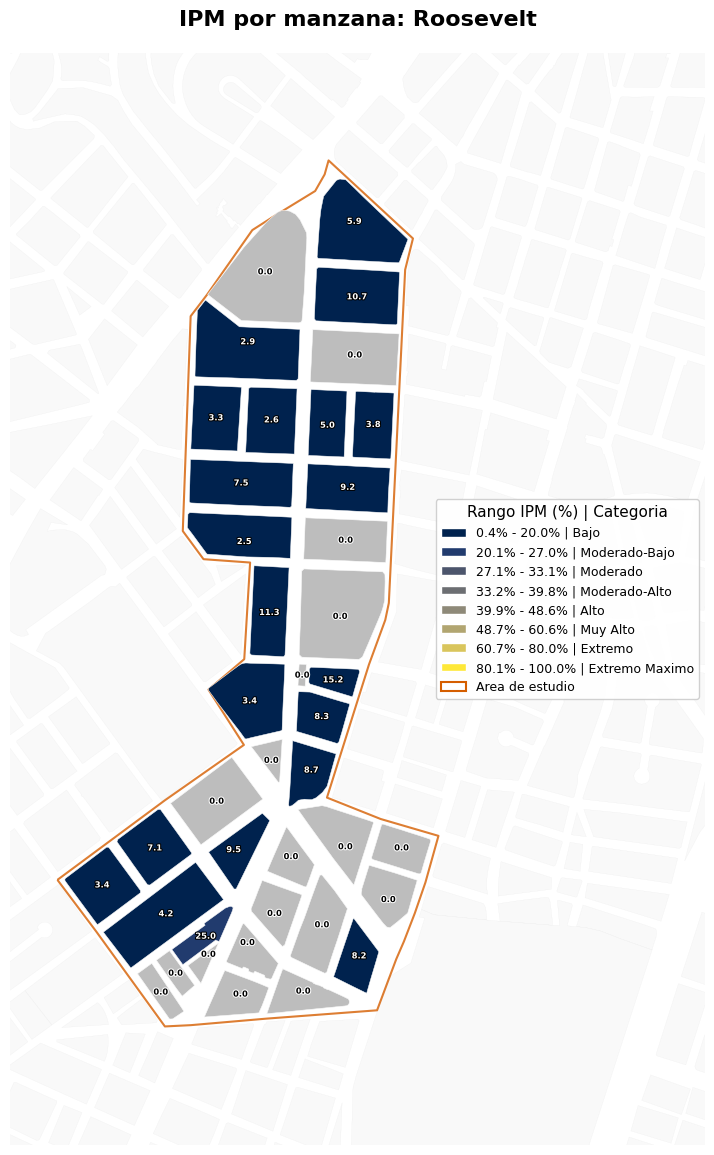

/tmp/ipykernel_46877/1704650157.py:74: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid), poly, how="inner", predicate="within")


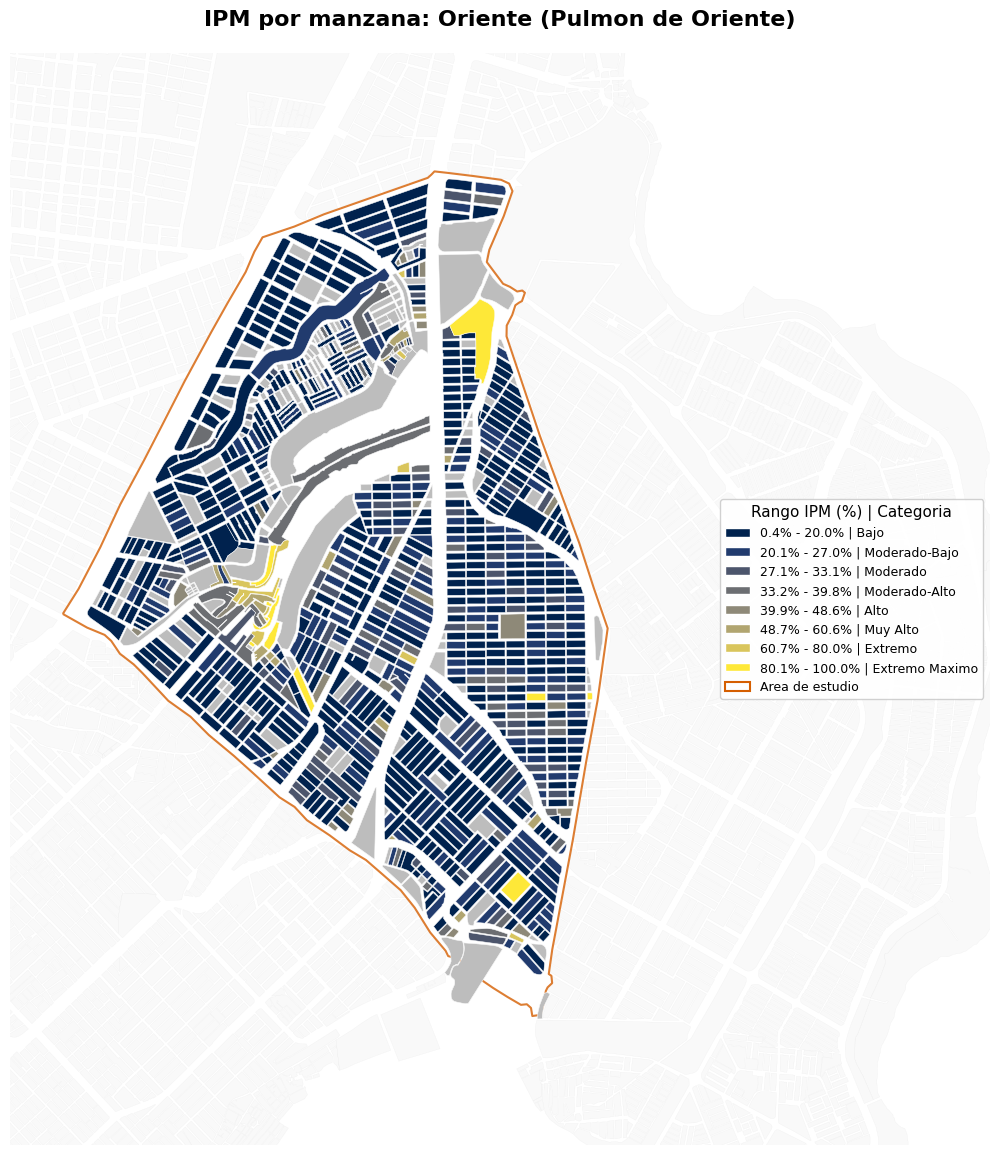

/tmp/ipykernel_46877/1704650157.py:74: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid), poly, how="inner", predicate="within")


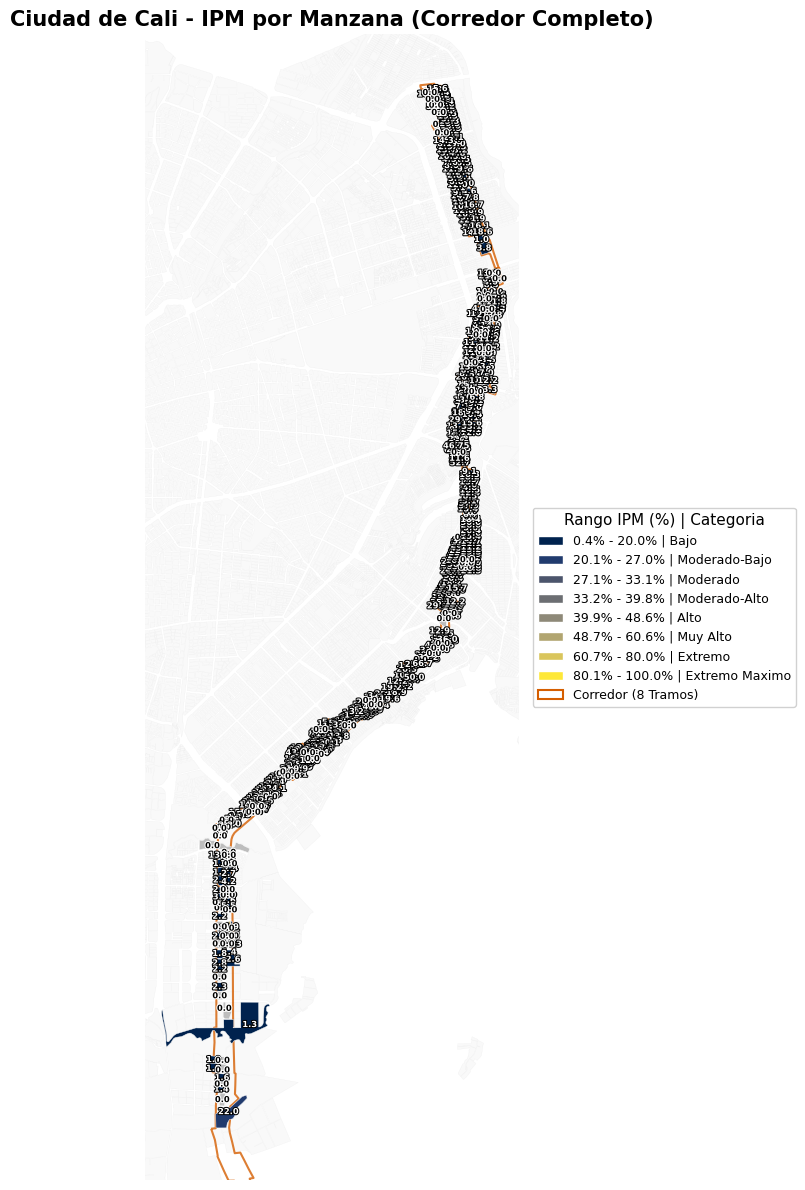

In [140]:
# @title 28. Mapas Detallados por Zona (Zoom Dinamico y Fondo Atenuado)
import matplotlib.colors as mcolors

RANGOS_IPM_8 = [
    (0.4, 20.0, "0.4% - 20.0%"),
    (20.1, 27.0, "20.1% - 27.0%"),
    (27.1, 33.1, "27.1% - 33.1%"),
    (33.2, 39.8, "33.2% - 39.8%"),
    (39.9, 48.6, "39.9% - 48.6%"),
    (48.7, 60.6, "48.7% - 60.6%"),
    (60.7, 80.0, "60.7% - 80.0%"),
    (80.1, 100.0, "80.1% - 100.0%"),
]
cmap_cividis_8 = plt.get_cmap("cividis", 8)
COLORES_IPM_8 = [mcolors.to_hex(cmap_cividis_8(i)) for i in range(8)]
CATEGORIAS_IPM_8 = ["Bajo", "Moderado-Bajo", "Moderado", "Moderado-Alto", "Alto", "Muy Alto", "Extremo", "Extremo Maximo"]

def _clasificar_ipm(gdf, columna="ipm"):
    datos = gdf[columna].astype(float)
    if datos.dropna().nunique() <= 1:
        minimo = float(datos.min()) if datos.notna().any() else 0.0
        maximo = float(datos.max()) if datos.notna().any() else 0.0
        return gdf.assign(_rango_ipm=f"{minimo:.1f}% - {maximo:.1f}%"), [f"{minimo:.1f}% - {maximo:.1f}%"], ["#BDBDBD"]
    cortes = [r[0] for r in RANGOS_IPM_8] + [RANGOS_IPM_8[-1][1]]
    etiquetas_8 = [r[2] for r in RANGOS_IPM_8]
    clasificada = gdf.copy()
    clasificada["_rango_ipm"] = pd.cut(datos, bins=cortes, labels=etiquetas_8, include_lowest=True, duplicates="drop")
    etiquetas_presentes = [et for et in etiquetas_8 if et in set(clasificada["_rango_ipm"].dropna().astype(str))]
    colores_presentes = [COLORES_IPM_8[etiquetas_8.index(et)] for et in etiquetas_presentes]
    return clasificada, etiquetas_presentes, colores_presentes


def _es_oriente(nombre):
    return "oriente" in nombre.lower() or "pulm" in nombre.lower()


def _agregar_etiquetas_ipm(ax, gdf, columna="ipm"):
    from matplotlib.patheffects import withStroke
    for _, fila in gdf.iterrows():
        if pd.isna(fila[columna]) or fila.geometry is None or fila.geometry.is_empty:
            continue
        punto = fila.geometry.representative_point()
        valor = float(fila[columna])
        txt_color = "white" if valor > 0 else "black"
        stroke_color = "black" if valor > 0 else "white"
        ax.text(
            punto.x, punto.y, f"{valor:.1f}",
            fontsize=6, ha="center", va="center", fontweight="bold",
            color=txt_color,
            path_effects=[withStroke(linewidth=1.5, foreground=stroke_color)]
        )


def _cuadrantes_cali(gdf_poly):
    from shapely.geometry import box
    minx, miny, maxx, maxy = gdf_poly.total_bounds
    midx = (minx + maxx) / 2
    midy = (miny + maxy) / 2
    return {
        "NO": box(minx, midy, midx, maxy),
        "NE": box(midx, midy, maxx, maxy),
        "SO": box(minx, miny, midx, midy),
        "SE": box(midx, miny, maxx, midy)
    }


for nom, poly in zonas_reporte.items():
    if poly is None:
        continue

    poly = poly.to_crs(gdf_ipm.crs)
    # Seleccion limpia por centroide para evitar manzanas perimetrales externas (>50% area)
    # Se usa el centroide para garantizar que la manzana pertenezca predominantemente a la zona
    mzn_zona = gpd.sjoin(gdf_ipm.copy().assign(geometry=gdf_ipm.centroid), poly, how="inner", predicate="within")
    mzn_zona.geometry = gdf_ipm.loc[mzn_zona.index].geometry
    mzn_zona = mzn_zona.drop(columns=[c for c in mzn_zona.columns if c.startswith("index_")], errors="ignore")

    es_cali = nom.lower() == "ciudad de cali"
    es_oriente = _es_oriente(nom)

    if es_cali:
        fig, ax = plt.subplots(1, 1, figsize=(18, 12))
        
        # Capa base (fondo de manzanas de Cali) - Llena todo el lienzo
        gdf_ipm.plot(ax=ax, color="#F8F8F8", edgecolor="#DCDCDC", linewidth=0.1, alpha=0.8, zorder=1)
        
        # Clasificar y plotear manzanas de la zona (los 8 tramos unificados)
        mzn_zona_cl, etiquetas_rango, colores_rango = _clasificar_ipm(mzn_zona, columna="ipm")
        colores = dict(zip(etiquetas_rango, colores_rango))
        mzn_zona_cl["_color_ipm"] = mzn_zona_cl["_rango_ipm"].astype(str).map(colores).fillna("#BDBDBD")
        
        mzn_zona_cl.plot(ax=ax, color=mzn_zona_cl["_color_ipm"], edgecolor="white", linewidth=0.3, zorder=3)
        
        # Contorno del area de estudio (los 8 tramos unificados)
        poly.boundary.plot(ax=ax, color="#D55E00", linewidth=1.5, linestyle="-", alpha=0.8, zorder=2)
        
        # Etiquetas de valor (white/black rule)
        _agregar_etiquetas_ipm(ax, mzn_zona_cl, columna="ipm")
        
        # Ajustar vista dinamica Atlas-style (Corredor a la izquierda, espacio para leyenda a la derecha)
        minx, miny, maxx, maxy = mzn_zona_cl.total_bounds
        rango_x = maxx - minx
        rango_y = maxy - miny
        ax.set_xlim(minx - rango_x*0.15, maxx + rango_x*0.75)
        ax.set_ylim(miny - rango_y*0.15, maxy + rango_y*0.15)
        
        # Leyenda clasificada integrada a la derecha sobre el fondo urbano
        handles_leyenda = []
        for i, rango in enumerate(RANGOS_IPM_8):
            etiqueta_leyenda = f"{rango[2]} | {CATEGORIAS_IPM_8[i]}"
            handles_leyenda.append(mpatches.Patch(facecolor=COLORES_IPM_8[i], edgecolor="white", label=etiqueta_leyenda))
        handles_leyenda.append(mpatches.Patch(facecolor="none", edgecolor="#D55E00", linewidth=1.5, label="Corredor (8 Tramos)"))
        
        ax.legend(handles=handles_leyenda, title="Rango IPM (%) | Categoria",
                   loc="center right", frameon=True, framealpha=0.9, fontsize=9, title_fontsize=11)
        
        ax.set_title(f"{nom} - IPM por Manzana (Corredor Completo)", fontsize=16, fontweight="bold", pad=20)
        ax.set_axis_off()
        plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.01)
        plt.show()

    else:
        fig, ax = plt.subplots(1, 1, figsize=(18, 12))

        # Capa base (fondo de manzanas de Cali) - Llena todo el lienzo
        gdf_ipm.to_crs(poly.crs).plot(
            ax=ax, color="#F8F8F8", edgecolor="#DCDCDC", linewidth=0.1, alpha=0.8, zorder=1
        )

        # Clasificar y plotear manzanas de la zona (estudio focalizado)
        mzn_zona_cl, etiquetas_rango, colores_rango = _clasificar_ipm(mzn_zona, columna="ipm")
        colores = dict(zip(etiquetas_rango, colores_rango))
        mzn_zona_cl["_color_ipm"] = mzn_zona_cl["_rango_ipm"].astype(str).map(colores).fillna("#BDBDBD")

        mzn_zona_cl.plot(ax=ax, color=mzn_zona_cl["_color_ipm"], edgecolor="white", linewidth=0.35, zorder=3)
        
        # Contorno destacado del area de estudio
        poly.boundary.plot(ax=ax, color="#D55E00", linewidth=1.5, linestyle="-", alpha=0.8, zorder=2)

        if not es_oriente:
            _agregar_etiquetas_ipm(ax, mzn_zona_cl, columna="ipm")

        # Ajustar vista dinamica centrada en la zona de estudio (con espacio extra a la derecha para leyenda)
        minx, miny, maxx, maxy = mzn_zona_cl.total_bounds
        rango_x = maxx - minx
        rango_y = maxy - miny
        
        # Expandimos hacia la derecha (0.7 extra) para que el fondo de manzanas cubra el area de la leyenda
        ax.set_xlim(minx - rango_x*0.15, maxx + rango_x*0.75)
        ax.set_ylim(miny - rango_y*0.15, maxy + rango_y*0.15)

        # Leyenda estandarizada posicionada sobre el fondo de manzanas
        handles_leyenda = []
        for i, rango in enumerate(RANGOS_IPM_8):
            etiqueta_leyenda = f"{rango[2]} | {CATEGORIAS_IPM_8[i]}"
            handles_leyenda.append(mpatches.Patch(facecolor=COLORES_IPM_8[i], edgecolor="white", label=etiqueta_leyenda))
        handles_leyenda.append(mpatches.Patch(facecolor="none", edgecolor="#D55E00", linewidth=1.5, label="Area de estudio"))

        ax.legend(handles=handles_leyenda, title="Rango IPM (%) | Categoria",
                  loc="center right", frameon=True, framealpha=0.9, fontsize=9, title_fontsize=11)
        
        ax.set_title(f"IPM por manzana: {nom}", fontsize=16, fontweight="bold", pad=20)
        ax.set_axis_off()
        plt.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.01)
        plt.show()


In [141]:
# @title 29. Tablas de Resumen por Comuna (Orden Ascendente 1-22)
def _orden_comuna(valor):
    numero = pd.to_numeric(pd.Series([valor]).astype(str).str.extract(r"(\d+)")[0], errors="coerce").iloc[0]
    return numero if pd.notna(numero) else 999


ics_comuna = gdf_ics_con_comuna.groupby(["comuna", "nombre"], dropna=False).agg(
    manzanas_ics=("ics", "count"),
    ICS_promedio=("ics", "mean")
).reset_index()

ipm_comuna = gdf_ipm_con_comuna.groupby(["comuna", "nombre"], dropna=False).agg(
    manzanas_ipm=("ipm", "count"),
    IPM_promedio=("ipm", "mean")
).reset_index()

df_comunas = ics_comuna.merge(ipm_comuna, on=["comuna", "nombre"], how="outer")
df_comunas["_orden"] = df_comunas["comuna"].apply(_orden_comuna)
df_comunas = df_comunas.sort_values(["_orden", "nombre"]).drop(columns="_orden")

print("=== Promedios por comuna ordenados de Comuna 1 a Comuna 22 ===")
display(df_comunas[["comuna", "nombre", "manzanas_ics", "ICS_promedio", "manzanas_ipm", "IPM_promedio"]].round(1))


=== Promedios por comuna ordenados de Comuna 1 a Comuna 22 ===


,comuna,nombre,manzanas_ics,ICS_promedio,manzanas_ipm,IPM_promedio
0,1.0,Comuna 1,271,24.8,271,17.0
1,2.0,Comuna 2,900,44.4,900,4.4
2,3.0,Comuna 3,372,26.2,372,12.5
3,4.0,Comuna 4,537,28.1,537,9.3
4,5.0,Comuna 5,635,35.6,635,4.8
5,6.0,Comuna 6,893,29.5,893,8.9
6,7.0,Comuna 7,491,28.1,491,13.4
7,8.0,Comuna 8,640,32.5,640,8.6
8,9.0,Comuna 9,380,29.7,380,10.4
9,10.0,Comuna 10,616,34.9,616,6.0


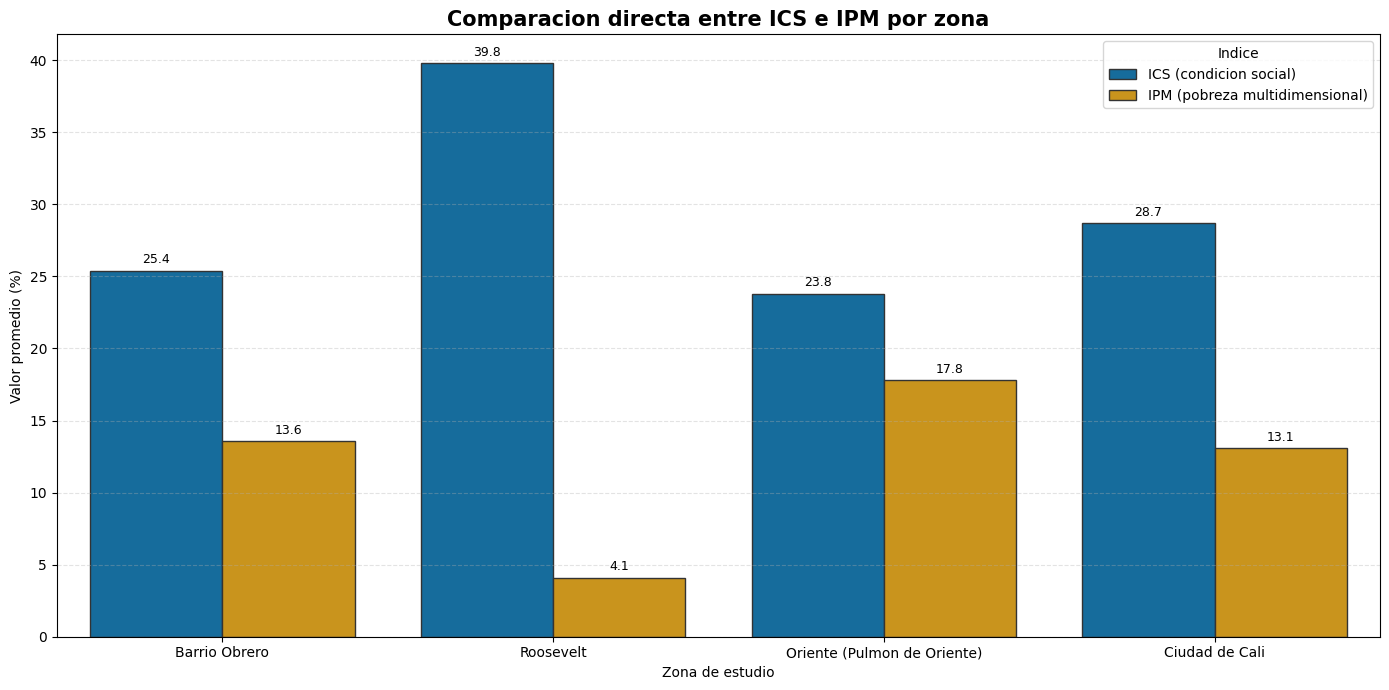

Indice,ICS (condicion social),IPM (pobreza multidimensional)
Zona,,
Barrio Obrero,25.4,13.6
Ciudad de Cali,28.7,13.1
Oriente (Pulmon de Oriente),23.8,17.8
Roosevelt,39.8,4.1


In [142]:
# @title 30. Grafico - Comparativa ICS vs IPM (Con Data Labels)
comp_list = []
for nom, poly in zonas_reporte.items():
    if poly is not None:
        poly_match = poly.to_crs(gdf_ics.crs)
        v_ics = gpd.sjoin(gdf_ics, poly_match[["geometry"]], how="inner", predicate="within")["ics"].mean()
        v_ipm = gpd.sjoin(gdf_ipm, poly_match.to_crs(gdf_ipm.crs)[["geometry"]], how="inner", predicate="within")["ipm"].mean()
        comp_list.append({"Zona": nom, "Valor promedio (%)": round(v_ics, 1), "Indice": "ICS (condicion social)"})
        comp_list.append({"Zona": nom, "Valor promedio (%)": round(v_ipm, 1), "Indice": "IPM (pobreza multidimensional)"})

df_graf = pd.DataFrame(comp_list)

fig, ax = plt.subplots(figsize=(14, 7))
PALETA_INDICES = {
    "ICS (condicion social)": "#0072B2",
    "IPM (pobreza multidimensional)": "#E69F00"
}
sns.barplot(
    data=df_graf,
    x="Zona", y="Valor promedio (%)", hue="Indice",
    palette=PALETA_INDICES, edgecolor="#333333", ax=ax
)
ax.set_title("Comparacion directa entre ICS e IPM por zona", fontsize=15, fontweight="bold")
ax.set_xlabel("Zona de estudio")
ax.set_ylabel("Valor promedio (%)")
ax.grid(axis="y", linestyle="--", alpha=0.35)
for contenedor in ax.containers:
    ax.bar_label(contenedor, fmt="%.1f", padding=3, fontsize=9)
ax.legend(title="Indice", frameon=True)
plt.tight_layout()
plt.show()

display(df_graf.pivot_table(index="Zona", columns="Indice", values="Valor promedio (%)", aggfunc="mean").round(1))


In [143]:
# @title 31. Validacion final y limpieza
def validar_final():
    print("Verificando consistencia final de las secciones 25 a 31...")

    objetos_requeridos = {
        "zonas_reporte": "diccionario de zonas del reporte",
        "df_ipm_comp": "tabla de IPM global por zona",
        "df_plot_top5": "tabla del Top 5 de carencias IPM",
        "df_comunas": "tabla resumen por comuna",
        "df_graf": "tabla comparativa ICS e IPM"
    }
    faltantes = [nombre for nombre in objetos_requeridos if nombre not in globals()]
    if faltantes:
        raise NameError("Faltan objetos requeridos: " + ", ".join(faltantes))

    zonas_faltantes = [zona for zona in zonas_reporte if zonas_reporte[zona] is None]
    if zonas_faltantes:
        raise ValueError("Faltan zonas en el analisis: " + ", ".join(zonas_faltantes))

    if not any("oriente" in z.lower() for z in zonas_reporte):
        raise ValueError("El poligono Oriente, equivalente a Pulmon de Oriente, no quedo integrado.")

    if "comuna" in df_comunas.columns:
        orden_comunas = df_comunas["comuna"].dropna().astype(str).str.extract(r"(\d+)")[0].astype(float).tolist()
        if orden_comunas != sorted(orden_comunas):
            raise ValueError("La tabla por comuna no esta ordenada de menor a mayor.")

    for gdf_nombre in ["gdf_ics", "gdf_ipm", "gdf_vars"]:
        if gdf_nombre in globals():
            globals()[gdf_nombre].drop(columns=[c for c in globals()[gdf_nombre].columns if c.startswith("index_") or c == "level_0"], inplace=True, errors="ignore")

    print("OK Zonas requeridas integradas: Barrio Obrero, Roosevelt, Oriente y Ciudad de Cali.")
    print("OK Oriente queda tratado como Pulmon de Oriente en analisis y mapas.")
    print("OK Mapas individuales con contorno #D55E00 (Naranja Vermellon, accesible daltonismo).")
    print("OK Barra de rangos IPM vertical con leyenda clasificada.")
    print("OK Sin etiquetas IPM en mapa de Oriente (evita saturacion visual).")
    print("OK Ciudad de Cali fraccionada en 4 cuadrantes (layout 2x2).")
    print("OK Tablas por comuna ordenadas de Comuna 1 a Comuna 22.")
    print("OK Grafico ICS vs IPM con etiquetas de datos a 1 decimal.")
    print("OK Texto, etiquetas y titulos en espanol colombiano y UTF-8.")


validar_final()


Verificando consistencia final de las secciones 25 a 31...
OK Zonas requeridas integradas: Barrio Obrero, Roosevelt, Oriente y Ciudad de Cali.
OK Oriente queda tratado como Pulmon de Oriente en analisis y mapas.
OK Mapas individuales con contorno #D55E00 (Naranja Vermellon, accesible daltonismo).
OK Barra de rangos IPM vertical con leyenda clasificada.
OK Sin etiquetas IPM en mapa de Oriente (evita saturacion visual).
OK Ciudad de Cali fraccionada en 4 cuadrantes (layout 2x2).
OK Tablas por comuna ordenadas de Comuna 1 a Comuna 22.
OK Grafico ICS vs IPM con etiquetas de datos a 1 decimal.
OK Texto, etiquetas y titulos en espanol colombiano y UTF-8.
